## AGN Project: *Characterization of Galaxies via Optical and Infrared Surveys*

### Notebook Preamble

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

import scipy as sci
import pandas as pd
import numpy as np
import matplotlib as mpl

preamble = r'''
    \usepackage{amsmath}
    \usepackage{amssymb}
    \usepackage{mathtools}
    
    \usepackage{fontspec}
    \usepackage{unicode-math}
    \setmainfont{TeX Gyre Termes}
    \setmathfont{TeX Gyre Termes Math}
    
    \usepackage{microtype}
    
    \usepackage[
    	locale = US,
    	per-mode = power,
    	print-zero-exponent = true,
    	print-unity-mantissa = false
    ]{siunitx}
    
    \DeclareSIUnit{\year}{yr}
    \DeclareSIUnit{\erg}{erg}
    \DeclareSIUnit{\parsec}{pc}
    \DeclareSIUnit{\angstrom}{\text{\AA}}
    \DeclareSIUnit{\solarmass}{\ensuremath{M_\odot}}
    
    \def\mathdefault#1{#1}
'''

mpl.rcParams.update({
    "axes.prop_cycle": "cycler('color', ['firebrick', 'goldenrod', 'olivedrab', 'steelblue', 'rebeccapurple'])",

    "backend": 'pgf',
    
    "figure.figsize": [3.25, 2.44],
    "figure.constrained_layout.use": True,
    "font.family": 'serif',
    
    "axes.labelsize": 'small',
    
    "font.size": 10,
    
    "legend.fontsize": 'small',
    "legend.frameon": False,
    "legend.handlelength": 1.5,
    "legend.columnspacing": 1.5,
    "legend.handletextpad": 0.6,
    
    "xtick.labelsize": 'small',
    "xtick.minor.visible": True,
    "xtick.direction": 'in',
    "xtick.top": True,
    "ytick.labelsize": 'small',
    "ytick.minor.visible": True,
    "ytick.direction": 'in',
    "ytick.right": True,
    
    "pgf.rcfonts": False,
    
    "text.usetex": True,
    "pgf.texsystem": 'lualatex',
    "pgf.preamble": preamble
})

from scipy.spatial import distance_matrix
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

from sklearn.metrics import matthews_corrcoef

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.path import Path
from matplotlib.colors import ListedColormap

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)
FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)
GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)
OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)
SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(102/256, 1, N)
vals[:, 1] = np.linspace(51/256, 1, N)
vals[:, 2] = np.linspace(153/256, 1, N)
RebeccaPurple = ListedColormap(vals)
RebeccaPurple_r = RebeccaPurple.reversed()

rng = np.random.default_rng(seed=123)

figures = {}

### [SkyServer Query](https://skyserver.sdss.org/dr19/SearchTools/sql)

```sql
SELECT TOP 10000
    g.sii_6717_flux, g.sii_6731_flux, g.nii_6584_flux, g.oi_6300_flux, g.oiii_5007_flux,
    g.h_alpha_flux, g.h_beta_flux,
    g.h_alpha_eqw, g.nii_6584_eqw, g.oiii_sigma,
    w.w1mpro, w.w2mpro, w.w3mpro,
    s.z, s.class, s.subclass, s.bestobjid
FROM SpecObj AS s
    JOIN galSpecLine AS g ON s.specobjid = g.specobjid
    JOIN PhotoTag AS p ON s.bestobjid = p.objid
    OUTER APPLY (   SELECT TOP 1 x.wise_cntr
                    FROM wise_xmatch AS x
                    WHERE p.objid = x.sdss_objid AND x.match_dist < 3
                    ORDER BY x.match_dist ASC
                ) AS y
    LEFT JOIN wise_allsky AS w ON y.wise_cntr = w.cntr
WHERE s.class = 'GALAXY'
    AND s.subclass != 'BROADLINE'
    AND s.subclass != 'AGN BROADLINE'
    AND s.subclass != 'STARFORMING BROADLINE'
    AND s.subclass != 'STARBURST BROADLINE'
    AND s.snmedian_r > 5.0
    AND s.z < 0.35
    AND g.sii_6717_eqw < 0
    AND g.sii_6731_eqw < 0
    AND g.nii_6584_eqw < 0
    AND g.oi_6300_eqw < 0
    AND g.oiii_5007_eqw < 0
    AND g.h_alpha_eqw < 0
    AND g.h_beta_eqw < 0
    AND (2.355 * g.sigma_forbidden) < 500
    AND (2.355 * g.sigma_balmer) < 500
    AND g.sii_6717_flux > 3 * g.sii_6717_flux_err
    AND g.sii_6731_flux > 3 * g.sii_6731_flux_err
    AND g.nii_6584_flux > 3 * g.nii_6584_flux_err
    AND g.oi_6300_flux > 3 * g.oi_6300_flux_err
    AND g.oiii_5007_flux > 3 * g.oiii_5007_flux_err
    AND g.h_alpha_flux > 3 * g.h_alpha_flux_err
    AND g.h_beta_flux > 3 * g.h_beta_flux_err
ORDER BY s.specobjid ASC
```

### Dataframe Loading

In [2]:
df = pd.read_csv('data.csv', skiprows=1)

counts = df['bestobjid'].value_counts()

print(f'\nFound a Total of {len(df)} SDSS Objects, with {len(df.dropna(subset=['w1mpro', 'w2mpro', 'w3mpro']))} Matches to the WISE Database.',
      f'There are {len(counts[counts > 1])} Duplicates in this Table.\n',
      f'\nIncluded GALAXY Subclasses: {' '.join(map(str, df['subclass'].dropna().unique()))}\n')

df.head(15).style.hide()


Found a Total of 10000 SDSS Objects, with 9799 Matches to the WISE Database. There are 0 Duplicates in this Table.
 
Included GALAXY Subclasses: STARFORMING STARBURST AGN



sii_6717_flux,sii_6731_flux,nii_6584_flux,oi_6300_flux,oiii_5007_flux,h_alpha_flux,h_beta_flux,h_alpha_eqw,nii_6584_eqw,oiii_sigma,w1mpro,w2mpro,w3mpro,z,class,subclass,bestobjid
35.334970,21.657780,51.591550,8.490424,21.444370,99.400050,25.640470,-5.130115,-2.528958,182.796000,13.538000,13.469000,11.074000,0.064656,GALAXY,STARFORMING,1237650795146445031
30.269960,25.722970,25.789630,6.269853,35.466710,127.305800,38.332260,-21.187690,-3.849116,5.724757,15.291000,15.156000,12.344000,0.052654,GALAXY,STARFORMING,1237648720142401670
36.779390,37.110670,58.870900,12.491980,20.207150,77.048040,22.933670,-4.769841,-3.612301,326.581400,13.812000,13.572000,11.127000,0.134680,GALAXY,STARFORMING,1237650795683512507
80.135600,70.843640,367.876300,19.599120,55.355480,510.664700,91.710970,-15.408550,-10.877340,88.712100,12.901000,12.695000,8.763000,0.048086,GALAXY,STARFORMING,1237650796220514489
48.689910,36.945600,147.909000,7.274137,18.083990,351.304500,66.982060,-22.022530,-9.346472,101.350100,13.149000,12.906000,9.260000,0.065183,GALAXY,STARFORMING,1237648720142336237
194.402200,153.680800,563.458600,32.057770,95.847920,1151.211000,257.940900,-38.925330,-18.940330,127.924000,13.091000,12.818000,9.317000,0.064902,GALAXY,STARFORMING,1237648720142336185
140.534800,110.589700,384.858900,30.056240,203.211000,919.356400,194.093000,-59.879910,-25.235250,133.140200,14.109000,13.638000,9.283000,0.114679,GALAXY,nan,1237650795146379447
31.040920,17.307790,56.051570,6.340064,10.572200,144.651800,30.730270,-8.484818,-3.203966,71.449490,13.580000,13.449000,10.118000,0.060614,GALAXY,STARFORMING,1237651799621959813
42.041940,28.548300,64.894130,13.768800,46.406440,131.258900,34.240510,-4.757507,-2.194183,113.018400,13.732000,13.769000,10.907000,0.056548,GALAXY,STARFORMING,1237650795683446947
57.435880,40.396540,149.090700,9.482595,16.896020,435.409100,104.516500,-27.603120,-9.634499,95.077220,13.923000,13.717000,9.705000,0.065110,GALAXY,STARFORMING,1237648720679338241


### Derived Values

In [3]:
print(f'\nRatios of SDSS Classes:  SF = {100 * len(df[df['subclass'] == 'STARFORMING']) / len(df):.0f}%  ',
      f'SB = {100 * len(df[df['subclass'] == 'STARBURST']) / len(df):.0f}%  ',
      f'AGN = {100 * len(df[df['subclass'] == 'AGN']) / len(df):.0f}%\n')

df[['oiii_h_beta_ratio', 'nii_h_alpha_ratio', 'w2_w3', 'w1_w2', 'el_gas_dens', 'bh_mass']] = np.nan
df[['bpt_class', 'whan_class', 'color_class']] = None

df['oiii_h_beta_ratio'] = df['oiii_5007_flux'] / df['h_beta_flux']
df['nii_h_alpha_ratio'] = df['nii_6584_flux'] / df['h_alpha_flux']
df['w2_w3'] = df['w2mpro'] - df['w3mpro']
df['w1_w2'] = df['w1mpro'] - df['w2mpro']

def el_gas_dens(flux1, flux2, a = 0.4315, b = 2107.0, c = 627.1, Rmin = 0.4375, Rmax = 1.4484):
    'Estimate Electron / Gas Density Using Line Ratios (Sanders et al. 2016)'
    if flux2 == 0.0:
        return np.nan
    R = flux1 / flux2
    if (R >= Rmin) & (R <= Rmax):
        return (c * R - b * a) / (a - R)
    return np.nan

df['el_gas_dens'] = np.vectorize(el_gas_dens)(df['sii_6717_flux'].values, df['sii_6731_flux'].values)

def bh_mass(s, s0 = 200.0, alpha = 8.13, beta = 4.02):
    'Estimate Black Hole Mass Using Galactic Velocity Dispersion (Tremaine et al. 2002)'
    x = np.log10(s / s0)
    y = alpha + beta * x
    return 10**y

df['bh_mass'] = bh_mass(df['oiii_sigma'])

def kewley_discrim_r(r, a = 0.61, b = -0.47, c = 1.19):
    'Classify Galaxies Using Analytical Line Ratio Relation (Kewley et al. 2001)'
    def helper(r, a, b, c):
        if r < 10**(-b):
            return 10**(a / (np.log10(r) + b) + c)
        else:
            return 0.0
    return np.vectorize(helper)(r, a, b, c)

def kauffmann_discrim_r(r, a = 0.61, b = -0.05, c = 1.3):
    'Classify Galaxies Using Empirical Line Ratio Relation (Kauffmann et al. 2003)'
    def helper(r, a, b, c):
        if r < 10**(-b):
            return 10**(a / (np.log10(r) + b) + c)
        else:
            return 0.0
    return np.vectorize(helper)(r, a, b, c)

mask = df['oiii_h_beta_ratio'] > kewley_discrim_r(df['nii_h_alpha_ratio'])
df.loc[mask, 'bpt_class'] = 'AGN'

mask = (df['oiii_h_beta_ratio'] <= kewley_discrim_r(df['nii_h_alpha_ratio'])) & (df['oiii_h_beta_ratio'] >= kauffmann_discrim_r(df['nii_h_alpha_ratio']))
df.loc[mask, 'bpt_class'] = 'COMP'

mask = df['oiii_h_beta_ratio'] < kauffmann_discrim_r(df['nii_h_alpha_ratio'])
df.loc[mask, 'bpt_class'] = 'SF'

print(f'Ratios of BPT Classes:   SF = {100 * len(df[df['bpt_class'] == 'SF']) / len(df):.0f}%  ',
      f'COMP = {100 * len(df[df['bpt_class'] == 'COMP']) / len(df):.0f}%  ',
      f'AGN = {100 * len(df[df['bpt_class'] == 'AGN']) / len(df):.0f}%\n')

df.loc[(df['nii_h_alpha_ratio'] < 10**(-0.4)) & (-df['h_alpha_eqw'] > 3.0), 'whan_class'] = 'Pure SF'
df.loc[(df['nii_h_alpha_ratio'] > 10**(-0.4)) & (-df['h_alpha_eqw'] > 6.0), 'whan_class'] = 'Strong AGN'
df.loc[(df['nii_h_alpha_ratio'] > 10**(-0.4)) & (-df['h_alpha_eqw'] < 6.0) & (-df['h_alpha_eqw'] > 3.0), 'whan_class'] = 'Weak AGN'
df.loc[-df['h_alpha_eqw'] < 3.0, 'whan_class'] = 'Radio G'
df.loc[(-df['h_alpha_eqw'] < 0.5) & (-df['nii_6584_eqw'] < 0.5), 'whan_class'] = 'Passive G'

print(f'Ratios of WHAN Classes:  Pure SF = {100 * len(df[df['whan_class'] == 'Pure SF']) / len(df):.0f}%  ',
      f'Strong AGN = {100 * len(df[df['whan_class'] == 'Strong AGN']) / len(df):.0f}%  ',
      f'Weak AGN = {100 * len(df[df['whan_class'] == 'Weak AGN']) / len(df):.0f}%  ',
      f'Radio G = {100 * len(df[df['whan_class'] == 'Radio G']) / len(df):.0f}%  ',
      f'Passive G = {100 * len(df[df['bpt_class'] == 'Passive G']) / len(df):.0f}%\n')

def wedge_up(x, a = 0.315, b = 0.796):
    'Bounds Classification Wedge Upper Border (Mateos et al. 2012)'
    return a * x + b

def wedge_bot(x, a = 0.315, b = -0.222):
    'Bounds Classification Wedge Bottom Border (Mateos et al. 2012)'
    return a * x + b

def wedge_side(x, a = -3.172, b = 7.624):
    'Bounds Classification Wedge Side Border (Mateos et al. 2012)'
    return a * x + b

df.loc[(df['w1_w2'] <= wedge_up(df['w2_w3'])) &
       (df['w1_w2'] >= wedge_bot(df['w2_w3'])) &
       (df['w1_w2'] >= wedge_side(df['w2_w3'])), 'color_class'] = 'AGN'

print(f'Ratio of Color Class:    AGN = {100 * len(df[df['color_class'] == 'AGN']) / len(df):.0f}%\n')

df.head(30).style.hide()


Ratios of SDSS Classes:  SF = 61%   SB = 25%   AGN = 6%

Ratios of BPT Classes:   SF = 75%   COMP = 16%   AGN = 9%

Ratios of WHAN Classes:  Pure SF = 63%   Strong AGN = 31%   Weak AGN = 4%   Radio G = 3%   Passive G = 0%

Ratio of Color Class:    AGN = 1%



sii_6717_flux,sii_6731_flux,nii_6584_flux,oi_6300_flux,oiii_5007_flux,h_alpha_flux,h_beta_flux,h_alpha_eqw,nii_6584_eqw,oiii_sigma,w1mpro,w2mpro,w3mpro,z,class,subclass,bestobjid,oiii_h_beta_ratio,nii_h_alpha_ratio,w2_w3,w1_w2,el_gas_dens,bh_mass,bpt_class,whan_class,color_class
35.334970,21.657780,51.591550,8.490424,21.444370,99.400050,25.640470,-5.130115,-2.528958,182.796000,13.538000,13.469000,11.074000,0.064656,GALAXY,STARFORMING,1237650795146445031,0.836349,0.519029,2.395000,0.069000,nan,93964867.072954,COMP,Weak AGN,None
30.269960,25.722970,25.789630,6.269853,35.466710,127.305800,38.332260,-21.187690,-3.849116,5.724757,15.291000,15.156000,12.344000,0.052654,GALAXY,STARFORMING,1237648720142401670,0.925244,0.202580,2.812000,0.135000,229.742257,84.341785,SF,Pure SF,None
36.779390,37.110670,58.870900,12.491980,20.207150,77.048040,22.933670,-4.769841,-3.612301,326.581400,13.812000,13.572000,11.127000,0.134680,GALAXY,STARFORMING,1237650795683512507,0.881113,0.764080,2.445000,0.240000,514.085576,968512058.233081,COMP,Weak AGN,None
80.135600,70.843640,367.876300,19.599120,55.355480,510.664700,91.710970,-15.408550,-10.877340,88.712100,12.901000,12.695000,8.763000,0.048086,GALAXY,STARFORMING,1237650796220514489,0.603586,0.720387,3.932000,0.206000,285.593960,5137484.383070,COMP,Strong AGN,None
48.689910,36.945600,147.909000,7.274137,18.083990,351.304500,66.982060,-22.022530,-9.346472,101.350100,13.149000,12.906000,9.260000,0.065183,GALAXY,STARFORMING,1237648720142336237,0.269983,0.421028,3.646000,0.243000,93.331438,8775515.289300,SF,Strong AGN,None
194.402200,153.680800,563.458600,32.057770,95.847920,1151.211000,257.940900,-38.925330,-18.940330,127.924000,13.091000,12.818000,9.317000,0.064902,GALAXY,STARFORMING,1237648720142336185,0.371589,0.489449,3.501000,0.273000,139.062989,22377243.149485,SF,Strong AGN,None
140.534800,110.589700,384.858900,30.056240,203.211000,919.356400,194.093000,-59.879910,-25.235250,133.140200,14.109000,13.638000,9.283000,0.114679,GALAXY,nan,1237650795146379447,1.046977,0.418618,4.355000,0.471000,133.765810,26277401.785509,COMP,Strong AGN,None
31.040920,17.307790,56.051570,6.340064,10.572200,144.651800,30.730270,-8.484818,-3.203966,71.449490,13.580000,13.449000,10.118000,0.060614,GALAXY,STARFORMING,1237651799621959813,0.344032,0.387493,3.331000,0.131000,nan,2152464.179537,SF,Pure SF,None
42.041940,28.548300,64.894130,13.768800,46.406440,131.258900,34.240510,-4.757507,-2.194183,113.018400,13.732000,13.769000,10.907000,0.056548,GALAXY,STARFORMING,1237650795683446947,1.355308,0.494398,2.862000,-0.037000,nan,13599377.186197,COMP,Weak AGN,None
57.435880,40.396540,149.090700,9.482595,16.896020,435.409100,104.516500,-27.603120,-9.634499,95.077220,13.923000,13.717000,9.705000,0.065110,GALAXY,STARFORMING,1237648720679338241,0.161659,0.342415,4.012000,0.206000,17.730437,6787765.745866,SF,Pure SF,None


### Plotting

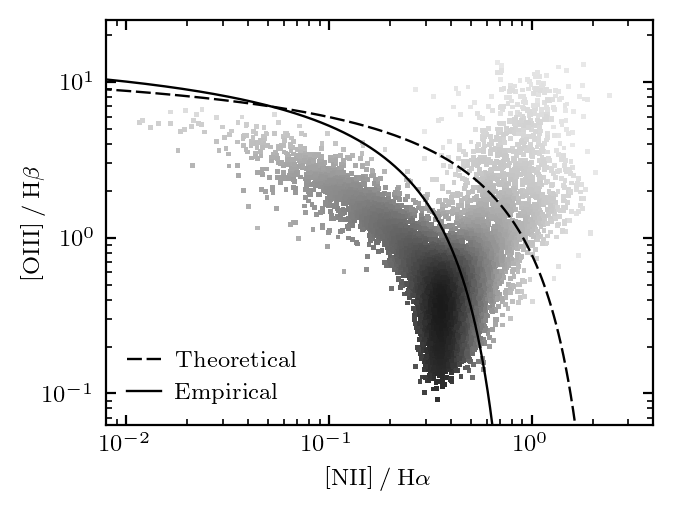

In [4]:
df_bpt = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['nii_h_alpha_ratio', 'oiii_h_beta_ratio'])

x = df_bpt['nii_h_alpha_ratio']
y = df_bpt['oiii_h_beta_ratio']

X = np.column_stack((x, y))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_color_rgb = np.array([0.1, 0.1, 0.1])

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1 
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (base_color_rgb - white) * adjusted_density[:, np.newaxis]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X[:, 0], X[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

xDisc = np.logspace(-3, 1, 333)
yKauf = kauffmann_discrim_r(xDisc)
yKewl = kewley_discrim_r(xDisc)

plt.plot(xDisc, yKewl, 'k', label='Theoretical',ls=(0, (6.3, 2)), lw=0.85)
plt.plot(xDisc, yKauf, 'k', label='Empirical', ls='-', lw=0.85)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=-0.75)

ax.legend()

figures['BPT_scatter'] = fig

plt.close()

figures['BPT_scatter']

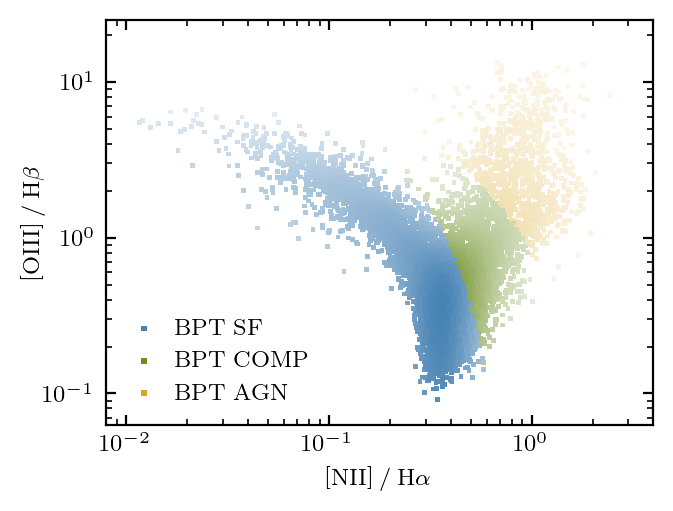

In [5]:
x1 = df_bpt['nii_h_alpha_ratio'][df_bpt['bpt_class'] == 'SF']
y1 = df_bpt['oiii_h_beta_ratio'][df_bpt['bpt_class'] == 'SF']

x2 = df_bpt['nii_h_alpha_ratio'][df_bpt['bpt_class'] == 'COMP']
y2 = df_bpt['oiii_h_beta_ratio'][df_bpt['bpt_class'] == 'COMP']

x3 = df_bpt['nii_h_alpha_ratio'][df_bpt['bpt_class'] == 'AGN']
y3 = df_bpt['oiii_h_beta_ratio'][df_bpt['bpt_class'] == 'AGN']

cat1 = np.column_stack((x1, y1))
cat2 = np.column_stack((x2, y2))
cat3 = np.column_stack((x3, y3))

X = np.vstack([cat1, cat2, cat3])
categories = np.array([0]*len(x1) + [1]*len(x2) + [2]*len(x3))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_colors_rgb = np.array([
    [70/255, 130/255, 180/255],
    [107/255, 142/255, 35/255],
    [218/255, 165/255, 32/255]
])

point_base_colors = base_colors_rgb[categories]

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (point_base_colors - white) * adjusted_density[:, np.newaxis]

shuffle_indices = rng.permutation(len(X))

X_shuffled = X[shuffle_indices]
mixed_colors = mixed_colors[shuffle_indices]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X_shuffled[:, 0], X_shuffled[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.scatter([],[],marker='s', c='steelblue', s=4, edgecolor='none', label='BPT SF')
ax.scatter([],[],marker='s', c='olivedrab', s=4, edgecolor='none', label='BPT COMP')
ax.scatter([],[],marker='s', c='goldenrod', s=4, edgecolor='none', label='BPT AGN')

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=-0.75)

ax.legend()

figures['BPT_class'] = fig

plt.close()

figures['BPT_class']

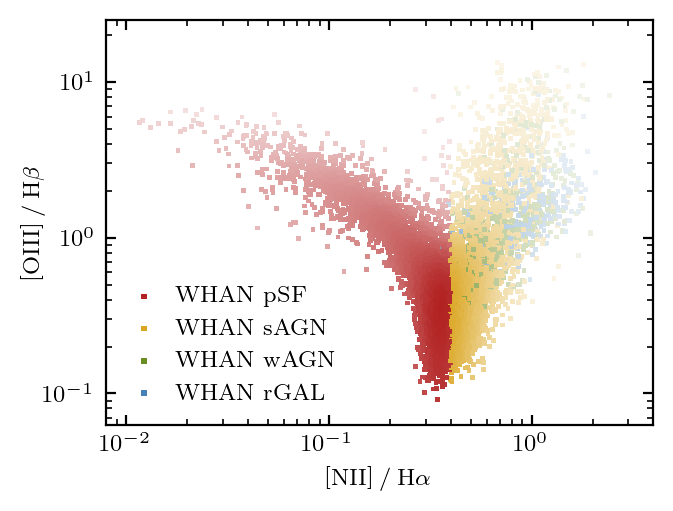

In [6]:
x1 = df_bpt['nii_h_alpha_ratio'][df_bpt['whan_class'] == 'Pure SF']
y1 = df_bpt['oiii_h_beta_ratio'][df_bpt['whan_class'] == 'Pure SF']

x2 = df_bpt['nii_h_alpha_ratio'][df_bpt['whan_class'] == 'Radio G']
y2 = df_bpt['oiii_h_beta_ratio'][df_bpt['whan_class'] == 'Radio G']

x3 = df_bpt['nii_h_alpha_ratio'][df_bpt['whan_class'] == 'Weak AGN']
y3 = df_bpt['oiii_h_beta_ratio'][df_bpt['whan_class'] == 'Weak AGN']

x4 = df_bpt['nii_h_alpha_ratio'][df_bpt['whan_class'] == 'Strong AGN']
y4 = df_bpt['oiii_h_beta_ratio'][df_bpt['whan_class'] == 'Strong AGN']

cat1 = np.column_stack((x1, y1))
cat2 = np.column_stack((x2, y2))
cat3 = np.column_stack((x3, y3))
cat4 = np.column_stack((x4, y4))

X = np.vstack([cat1, cat2, cat3, cat4])
categories = np.array([0]*len(x1) + [1]*len(x2) + [2]*len(x3) + [3]*len(x4))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_colors_rgb = np.array([
    [178/255, 34/255, 34/255],
    [70/255, 130/255, 180/255],
    [107/255, 142/255, 35/255],
    [218/255, 165/255, 32/255]
])

point_base_colors = base_colors_rgb[categories]

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (point_base_colors - white) * adjusted_density[:, np.newaxis]

shuffle_indices = rng.permutation(len(X))

X_shuffled = X[shuffle_indices]
mixed_colors = mixed_colors[shuffle_indices]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X_shuffled[:, 0], X_shuffled[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.scatter([], [], marker='s', c='firebrick', s=4, edgecolor='none', label='WHAN pSF')
ax.scatter([], [], marker='s', c='goldenrod', s=4, edgecolor='none', label='WHAN sAGN')
ax.scatter([], [], marker='s', c='olivedrab', s=4, edgecolor='none', label='WHAN wAGN')
ax.scatter([], [], marker='s', c='steelblue', s=4, edgecolor='none', label='WHAN rGAL')

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=-0.75)

ax.legend()

figures['BPT_WHAN_class'] = fig

plt.close()

figures['BPT_WHAN_class']

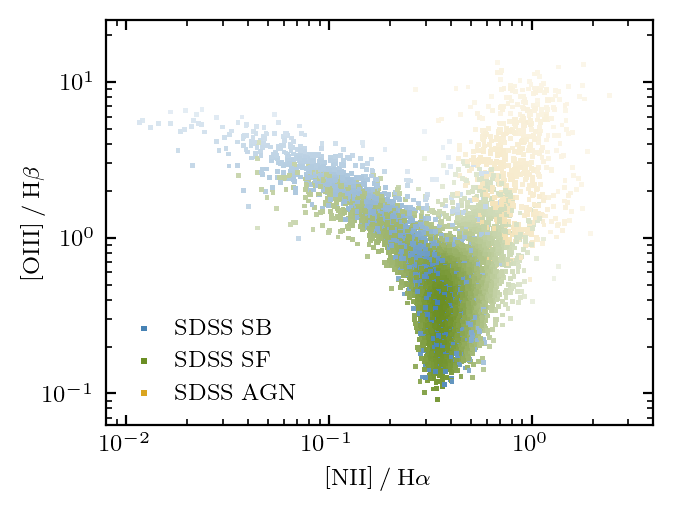

In [7]:
x1 = df_bpt['nii_h_alpha_ratio'][df_bpt['subclass'] == 'STARBURST']
y1 = df_bpt['oiii_h_beta_ratio'][df_bpt['subclass'] == 'STARBURST']

x2 = df_bpt['nii_h_alpha_ratio'][df_bpt['subclass'] == 'STARFORMING']
y2 = df_bpt['oiii_h_beta_ratio'][df_bpt['subclass'] == 'STARFORMING']

x3 = df_bpt['nii_h_alpha_ratio'][df_bpt['subclass'] == 'AGN']
y3 = df_bpt['oiii_h_beta_ratio'][df_bpt['subclass'] == 'AGN']

cat1 = np.column_stack((x1, y1))
cat2 = np.column_stack((x2, y2))
cat3 = np.column_stack((x3, y3))

X = np.vstack([cat1, cat2, cat3])
categories = np.array([0]*len(x1) + [1]*len(x2) + [2]*len(x3))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_colors_rgb = np.array([
    [70/255, 130/255, 180/255],
    [107/255, 142/255, 35/255],
    [218/255, 165/255, 32/255]
])

point_base_colors = base_colors_rgb[categories]

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (point_base_colors - white) * adjusted_density[:, np.newaxis]

shuffle_indices = rng.permutation(len(X))

X_shuffled = X[shuffle_indices]
mixed_colors = mixed_colors[shuffle_indices]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X_shuffled[:, 0], X_shuffled[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.scatter([],[],marker='s', c='steelblue', s=4, edgecolor='none', label='SDSS SB')
ax.scatter([],[],marker='s', c='olivedrab', s=4, edgecolor='none', label='SDSS SF')
ax.scatter([],[],marker='s', c='goldenrod', s=4, edgecolor='none', label='SDSS AGN')

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=-0.75)

ax.legend()

figures['BPT_SDSS_class'] = fig

plt.close()

figures['BPT_SDSS_class']

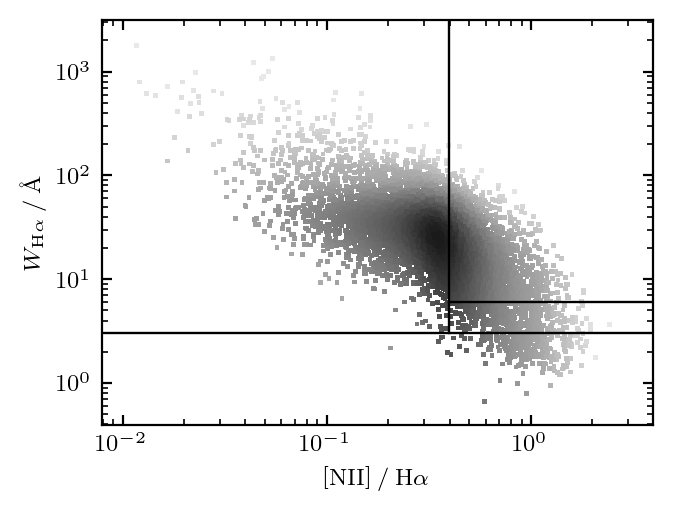

In [8]:
df_whan = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['nii_h_alpha_ratio', 'h_alpha_eqw'])

x = df_bpt['nii_h_alpha_ratio']
y = -df_bpt['h_alpha_eqw']

X = np.column_stack((x, y))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_color_rgb = np.array([0.1, 0.1, 0.1])

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1 
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (base_color_rgb - white) * adjusted_density[:, np.newaxis]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X[:, 0], X[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

plt.plot([10**(-0.4), 10**(-0.4)], [3.0, 1e4], 'k-', lw=0.85)
plt.plot([1e-3, 1e1], [3.0, 3.0], 'k-', lw=0.85)
plt.plot([10**(-0.4), 1e1], [6.0, 6.0], 'k-', lw=0.85)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -0.4, 3.5

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$W_\mathrm{H\alpha} \mathbin{/} \mathrm{\AA}$')

figures['WHAN_scatter'] = fig

plt.close()

figures['WHAN_scatter']

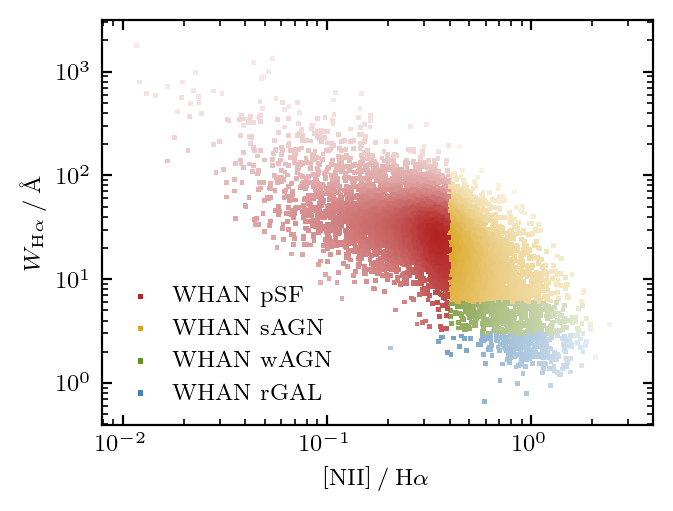

In [9]:
x1 = df_whan['nii_h_alpha_ratio'][df_whan['whan_class'] == 'Pure SF']
y1 = -df_whan['h_alpha_eqw'][df_whan['whan_class'] == 'Pure SF']

x2 = df_whan['nii_h_alpha_ratio'][df_whan['whan_class'] == 'Radio G']
y2 = -df_whan['h_alpha_eqw'][df_whan['whan_class'] == 'Radio G']

x3 = df_whan['nii_h_alpha_ratio'][df_whan['whan_class'] == 'Weak AGN']
y3 = -df_whan['h_alpha_eqw'][df_whan['whan_class'] == 'Weak AGN']

x4 = df_whan['nii_h_alpha_ratio'][df_whan['whan_class'] == 'Strong AGN']
y4 = -df_whan['h_alpha_eqw'][df_whan['whan_class'] == 'Strong AGN']

cat1 = np.column_stack((x1, y1))
cat2 = np.column_stack((x2, y2))
cat3 = np.column_stack((x3, y3))
cat4 = np.column_stack((x4, y4))

X = np.vstack([cat1, cat2, cat3, cat4])
categories = np.array([0]*len(x1) + [1]*len(x2) + [2]*len(x3) + [3]*len(x4))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_colors_rgb = np.array([
    [178/255, 34/255, 34/255],
    [70/255, 130/255, 180/255],
    [107/255, 142/255, 35/255],
    [218/255, 165/255, 32/255]
])

point_base_colors = base_colors_rgb[categories]

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1 
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (point_base_colors - white) * adjusted_density[:, np.newaxis]

shuffle_indices = rng.permutation(len(X))

X = X[shuffle_indices]
mixed_colors = mixed_colors[shuffle_indices]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X[:, 0], X[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -0.4, 3.5

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.scatter([], [], marker='s', c='firebrick', s=4, edgecolor='none', label='WHAN pSF')
ax.scatter([], [], marker='s', c='goldenrod', s=4, edgecolor='none', label='WHAN sAGN')
ax.scatter([], [], marker='s', c='olivedrab', s=4, edgecolor='none', label='WHAN wAGN')
ax.scatter([], [], marker='s', c='steelblue', s=4, edgecolor='none', label='WHAN rGAL')

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$W_\mathrm{H\alpha} \mathbin{/} \mathrm{\AA}$')

ax.legend()

figures['WHAN_class'] = fig

plt.close()

figures['WHAN_class']

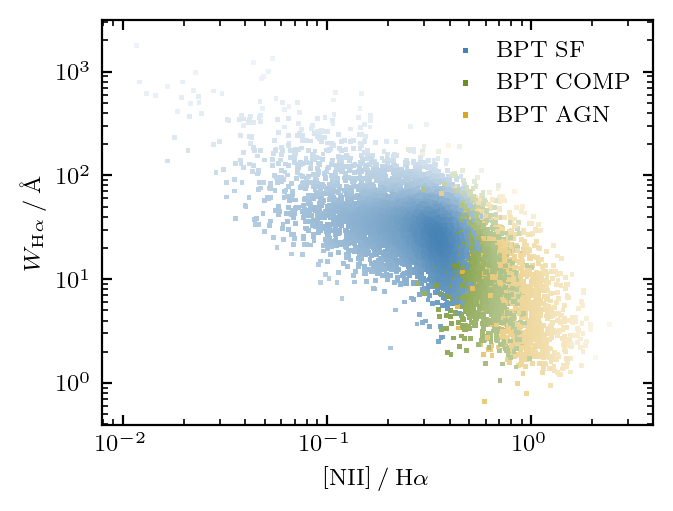

In [10]:
x1 = df_whan['nii_h_alpha_ratio'][df_whan['bpt_class'] == 'SF']
y1 = -df_whan['h_alpha_eqw'][df_whan['bpt_class'] == 'SF']

x2 = df_whan['nii_h_alpha_ratio'][df_whan['bpt_class'] == 'COMP']
y2 = -df_whan['h_alpha_eqw'][df_whan['bpt_class'] == 'COMP']

x3 = df_whan['nii_h_alpha_ratio'][df_whan['bpt_class'] == 'AGN']
y3 = -df_whan['h_alpha_eqw'][df_whan['bpt_class'] == 'AGN']

cat1 = np.column_stack((x1, y1))
cat2 = np.column_stack((x2, y2))
cat3 = np.column_stack((x3, y3))

X = np.vstack([cat1, cat2, cat3])
categories = np.array([0]*len(x1) + [1]*len(x2) + [2]*len(x3))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_colors_rgb = np.array([
    [70/255, 130/255, 180/255],
    [107/255, 142/255, 35/255],
    [218/255, 165/255, 32/255]
])

point_base_colors = base_colors_rgb[categories]

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1 
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (point_base_colors - white) * adjusted_density[:, np.newaxis]

shuffle_indices = rng.permutation(len(X))

X = X[shuffle_indices]
mixed_colors = mixed_colors[shuffle_indices]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X[:, 0], X[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -0.4, 3.5

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.scatter([],[],marker='s', c='steelblue', s=4, edgecolor='none', label='BPT SF')
ax.scatter([],[],marker='s', c='olivedrab', s=4, edgecolor='none', label='BPT COMP')
ax.scatter([],[],marker='s', c='goldenrod', s=4, edgecolor='none', label='BPT AGN')

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$W_\mathrm{H\alpha} \mathbin{/} \mathrm{\AA}$')

ax.legend()

figures['WHAN_BPT_class'] = fig

plt.close()

figures['WHAN_BPT_class']

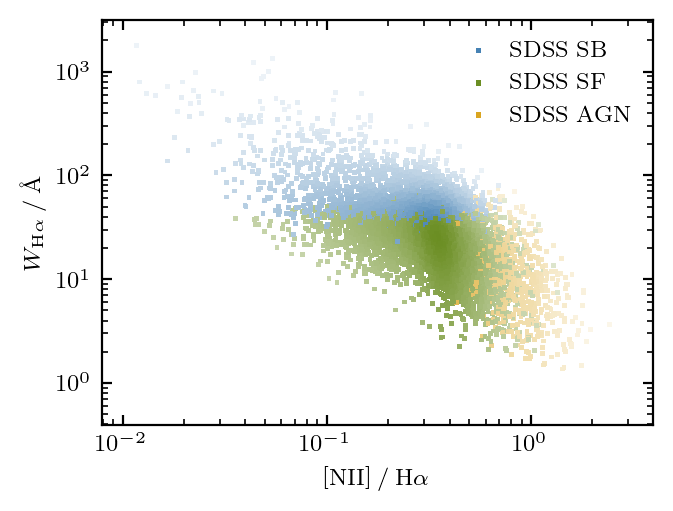

In [11]:
x1 = df_whan['nii_h_alpha_ratio'][df_whan['subclass'] == 'STARBURST']
y1 = -df_whan['h_alpha_eqw'][df_whan['subclass'] == 'STARBURST']

x2 = df_whan['nii_h_alpha_ratio'][df_whan['subclass'] == 'STARFORMING']
y2 = -df_whan['h_alpha_eqw'][df_whan['subclass'] == 'STARFORMING']

x3 = df_whan['nii_h_alpha_ratio'][df_whan['subclass'] == 'AGN']
y3 = -df_whan['h_alpha_eqw'][df_whan['subclass'] == 'AGN']

cat1 = np.column_stack((x1, y1))
cat2 = np.column_stack((x2, y2))
cat3 = np.column_stack((x3, y3))

X = np.vstack([cat1, cat2, cat3])
categories = np.array([0]*len(x1) + [1]*len(x2) + [2]*len(x3))

kde = gaussian_kde(X.T)
density_points = kde(X.T)

mod_density = density_points**0.3
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

base_colors_rgb = np.array([
    [70/255, 130/255, 180/255],
    [107/255, 142/255, 35/255],
    [218/255, 165/255, 32/255]
])

point_base_colors = base_colors_rgb[categories]

white = np.array([1.0, 1.0, 1.0])

min_weight = 0.1 
adjusted_density = min_weight + (1.0 - min_weight) * norm_density

mixed_colors = white + (point_base_colors - white) * adjusted_density[:, np.newaxis]

shuffle_indices = rng.permutation(len(X))

X = X[shuffle_indices]
mixed_colors = mixed_colors[shuffle_indices]

fig, ax = plt.subplots()
ax.set_facecolor('white')  

ax.scatter(X[:, 0], X[:, 1], marker='s', c=mixed_colors, s=3, edgecolor='none', alpha=1)

ax.set_xscale('log')
ax.set_yscale('log')

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -0.4, 3.5

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.scatter([],[],marker='s', c='steelblue', s=4, edgecolor='none', label='SDSS SB')
ax.scatter([],[],marker='s', c='olivedrab', s=4, edgecolor='none', label='SDSS SF')
ax.scatter([],[],marker='s', c='goldenrod', s=4, edgecolor='none', label='SDSS AGN')

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$W_\mathrm{H\alpha} \mathbin{/} \mathrm{\AA}$')

ax.legend()

figures['WHAN_SDSS_class'] = fig

plt.close()

figures['WHAN_SDSS_class']

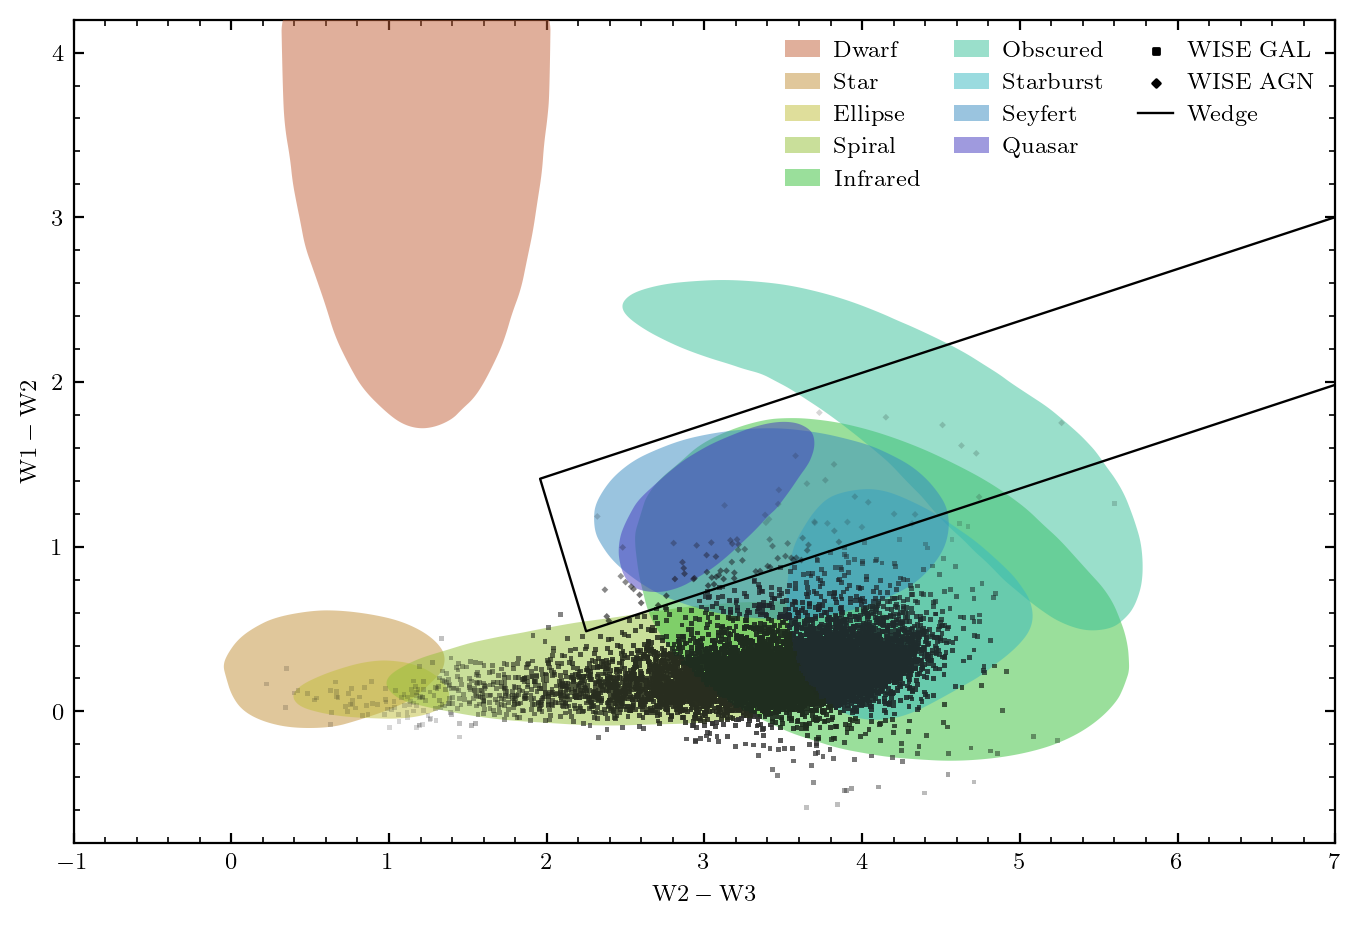

In [12]:
df_wise = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['w1_w2', 'w2_w3'])

xGAL = df_wise['w2_w3'][df_wise['color_class'] != 'AGN']
yGAL = df_wise['w1_w2'][df_wise['color_class'] != 'AGN']
xAGN = df_wise['w2_w3'][df_wise['color_class'] == 'AGN']
yAGN = df_wise['w1_w2'][df_wise['color_class'] == 'AGN']

cat1 = np.column_stack((xGAL, yGAL))
cat2 = np.column_stack((xAGN, yAGN))
n_gal = len(cat1) 

X = np.vstack([cat1, cat2])

kde = gaussian_kde(X.T)
density_points = kde(X.T)

clipped_density = np.clip(density_points, np.percentile(density_points, 1), density_points.max())
mod_density = clipped_density**0.5
d_min, d_max = mod_density.min(), mod_density.max()
norm_density = (mod_density - d_min) / (d_max - d_min)

def read_shapes(file_path, refine=5):
    x, y = np.genfromtxt(file_path, unpack=True, delimiter=',', skip_header=1)
    points = np.column_stack((x, y))
    dist_mat = distance_matrix(points, points)
    unvisited = list(range(len(points)))
    current = unvisited.pop(0)
    path = [current]
    while unvisited:
        nearest = min(unvisited, key=lambda idx: dist_mat[current, idx])
        unvisited.remove(nearest)
        path.append(nearest)
        current = nearest
    x, y = x[path], y[path]
    for _ in range(refine):
        closeX, closeY = np.append(x, x[0]), np.append(y, y[0])
        newX, newY = [], []
        for i in range(len(closeX) - 1):
            newX.extend([0.75 * closeX[i] + 0.25 * closeX[i+1], 0.25 * closeX[i] + 0.75 * closeX[i+1]])
            newY.extend([0.75 * closeY[i] + 0.25 * closeY[i+1], 0.25 * closeY[i] + 0.75 * closeY[i+1]])
        x, y = np.array(newX), np.array(newY)
    return x, y

x1, y1 = read_shapes('assets/shapes/dwarfs.csv')
x2, y2 = read_shapes('assets/shapes/stars.csv')
x3, y3 = read_shapes('assets/shapes/ellipticals.csv')
x4, y4 = read_shapes('assets/shapes/spirals.csv')
x5, y5 = read_shapes('assets/shapes/lirgs.csv')
x6, y6 = read_shapes('assets/shapes/obscureds.csv')
x7, y7 = read_shapes('assets/shapes/starbursts.csv')
x8, y8 = read_shapes('assets/shapes/seyferts.csv')
x9, y9 = read_shapes('assets/shapes/quasars.csv')


bg_colors = np.ones((len(X), 3))
a = 0.5
white = np.array([1.0, 1.0, 1.0])

shape_layers = [
    (x1, y1, '#c26138'), (x2, y2, '#c29038'), (x3, y3, '#c1bf38'),
    (x4, y4, '#94c137'), (x5, y5, '#37c139'), (x6, y6, '#37c098'),
    (x7, y7, '#37b9c0'), (x8, y8, '#368ac0'), (x9, y9, '#4136bf'),
]

for xs, ys, hex_color in shape_layers:
    fill_rgb = np.array(mcolors.to_rgb(hex_color))
    displayed_color = a * fill_rgb + (1.0 - a) * white
    
    poly_path = Path(np.column_stack((xs, ys)))
    inside_mask = poly_path.contains_points(X)
    bg_colors[inside_mask] = displayed_color

core_darkness = 0.2

min_alpha = 0.2

vector_rgba = np.zeros((len(X), 4))

vector_rgba[:, :3] = bg_colors * core_darkness

vector_rgba[:, 3] = min_alpha + (1.0 - min_alpha) * norm_density

fig, ax = plt.subplots(figsize=[6.69, 4.51])
ax.set_facecolor('white')

ax.fill(x1, y1, antialiased=True, alpha=a, color='#c26138', label='Dwarf', linewidth=0, zorder=10)
ax.fill(x2, y2, antialiased=True, alpha=a, color='#c29038', label='Star', linewidth=0, zorder=20)
ax.fill(x3, y3, antialiased=True, alpha=a, color='#c1bf38', label='Ellipse', linewidth=0, zorder=30)
ax.fill(x4, y4, antialiased=True, alpha=a, color='#94c137', label='Spiral', linewidth=0, zorder=40)
ax.fill(x5, y5, antialiased=True, alpha=a, color='#37c139', label='Infrared', linewidth=0, zorder=50)
ax.fill(x6, y6, antialiased=True, alpha=a, color='#37c098', label='Obscured', linewidth=0, zorder=60)
ax.fill(x7, y7, antialiased=True, alpha=a, color='#37b9c0', label='Starburst', linewidth=0, zorder=70)
ax.fill(x8, y8, antialiased=True, alpha=a, color='#368ac0', label='Seyfert', linewidth=0, zorder=80)
ax.fill(x9, y9, antialiased=True, alpha=a, color='#4136bf', label='Quasar', linewidth=0, zorder=90)
ax.plot([], [], ' ', label=' ')

x_wedge = [7, 6828/3487, 7846/3487, 7]
y_wedge = [3001/1000, 615809/435875, 212172/435875, 1983/1000]

ax.scatter(X[:n_gal, 0], X[:n_gal, 1], marker='s', c=vector_rgba[:n_gal], s=3, edgecolor='none', zorder=100)
ax.scatter(X[n_gal:, 0], X[n_gal:, 1], marker='D', c=vector_rgba[n_gal:], s=3, edgecolor='none', zorder=100)

ax.scatter([], [], marker='s', c='k', s=4, alpha=1, label=r'WISE GAL', zorder=120)
ax.scatter([], [], marker='D', c='k', s=4, alpha=1, label=r'WISE AGN', zorder=120)
ax.plot(x_wedge, y_wedge, 'k-', label='Wedge', lw=0.85, zorder=110)
ax.plot([], [], ' ', label=' ')
ax.plot([], [], ' ', label=' ')

ax.set_xlim(-1, 7)
ax.set_ylim(-0.8, 4.2)
ax.set_xlabel(r'$\mathrm{W2 - W3}$')
ax.set_ylabel(r'$\mathrm{W1 - W2}$')
ax.legend(ncols=3)

figures['WISE_overlay'] = fig
plt.close(fig)
figures['WISE_overlay']


Using 9990 overlapping rows as matching sample to compute the matrix.

Total number of positive categorizations by classifier:

SDSS:  585
BPT:   920
WHAN: 3464
WISE:   88

Total positives with optical and infrared agreement by classifier:

WISE & SDSS: 37
WISE & BPT:  47
WISE & WHAN: 58



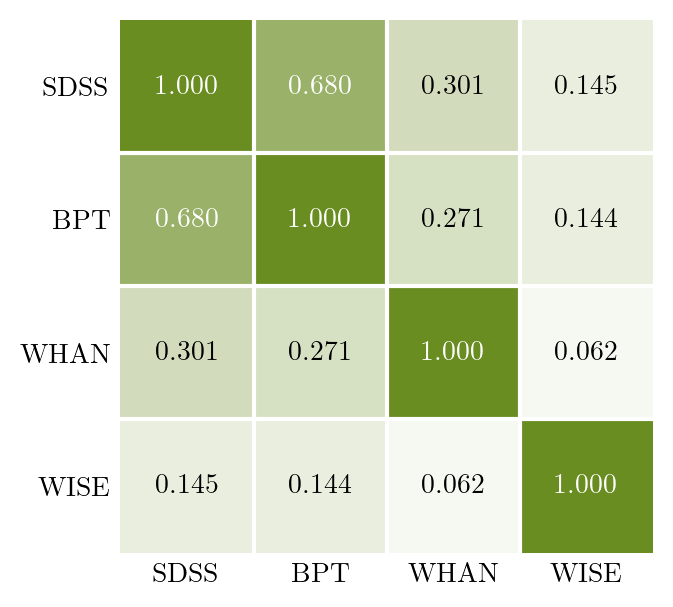

In [13]:
temp_df = pd.DataFrame(df)

agn_labels = {
    'subclass': ['AGN'],
    'bpt_class': ['AGN'],
    'whan_class': ['Strong AGN', 'Weak AGN'],
    'color_class': ['AGN']
}

non_agn_labels = {
    'subclass': ['STARFORMING', 'STARBURST', np.nan], 
    'bpt_class': ['SF', 'COMP', None], 
    'whan_class': ['Pure SF', 'Radio G', None], 
    'color_class': ['GAL', None] 
}

binary_columns = {}

for col in agn_labels.keys():
    df_str = temp_df[col].astype(str).str.strip()
    
    is_agn = df_str.isin(agn_labels[col])
    is_non_agn = df_str.isin(non_agn_labels[col])
    
    binary_series = pd.Series(np.nan, index=temp_df.index)
    binary_series[is_non_agn] = 0
    binary_series[is_agn] = 1
    
    binary_columns[col] = binary_series

working_df = pd.DataFrame(binary_columns).dropna().astype(int)

print(f'\nUsing {len(working_df)} overlapping rows as matching sample to compute the matrix.\n')

agn_counts = working_df.sum()

print('Total number of positive categorizations by classifier:\n')
print(f'SDSS: {agn_counts['subclass']:4.0f}')
print(f'BPT:  {agn_counts['bpt_class']:4.0f}')
print(f'WHAN: {agn_counts['whan_class']:4.0f}')
print(f'WISE: {agn_counts['color_class']:4.0f}\n')

match_subclass = ((working_df['color_class'] == 1) & (working_df['subclass'] == 1)).sum()
match_bpt      = ((working_df['color_class'] == 1) & (working_df['bpt_class'] == 1)).sum()
match_whan     = ((working_df['color_class'] == 1) & (working_df['whan_class'] == 1)).sum()

print('Total positives with optical and infrared agreement by classifier:\n')
print(f'WISE & SDSS: {match_subclass:>2}')
print(f'WISE & BPT:  {match_bpt:>2}')
print(f'WISE & WHAN: {match_whan:>2}\n')

labels = list(agn_labels.keys())
mcc_df = pd.DataFrame(index=labels, columns=labels, dtype=float)

for cat1 in labels:
    for cat2 in labels:
        mcc_df.loc[cat1, cat2] = matthews_corrcoef(working_df[cat1], working_df[cat2])

fig, ax = plt.subplots(figsize=(3.25, 3.25))

ax.set_frame_on(False)

im = ax.imshow(mcc_df.values, cmap=OliveDrab_r, vmin=0.0, vmax=1.0)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(['SDSS', 'BPT', 'WHAN', 'WISE'], fontsize=10)
ax.set_yticklabels(['SDSS', 'BPT', 'WHAN', 'WISE'], fontsize=10)

ax.tick_params(axis='both', which='both', length=0)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = mcc_df.values[i, j]
        text_color = "white" if abs(val) > 0.45 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=text_color, fontweight='medium')

ax.spines[:].set_visible(False)

for pos in np.arange(len(labels) - 1) + 0.5:
    ax.axvline(pos, color="white", linewidth=1.5)
    ax.axhline(pos, color="white", linewidth=1.5)

ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(len(labels) - 0.5, -0.5)

figures['MCC_strict'] = fig

plt.close()

figures['MCC_strict']


Using 9990 overlapping rows as matching sample to compute the matrix.

Total number of positive categorizations by classifier:

SDSS:  585
BPT:  2491
WHAN: 3464
WISE:   88

Total positives with optical and infrared agreement by classifier:

WISE & SDSS: 37
WISE & BPT:  64
WISE & WHAN: 58



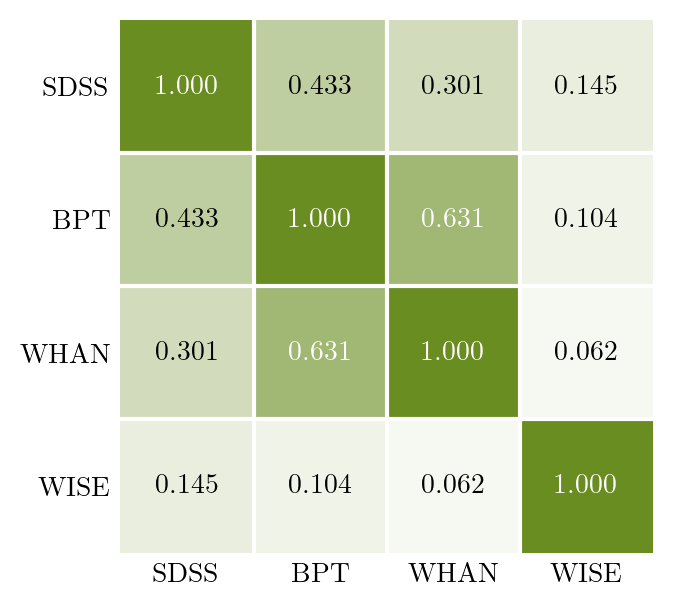

In [14]:
temp_df = pd.DataFrame(df)

agn_labels = {
    'subclass': ['AGN'],
    'bpt_class': ['AGN', 'COMP'],
    'whan_class': ['Strong AGN', 'Weak AGN'],
    'color_class': ['AGN']
}

non_agn_labels = {
    'subclass': ['STARFORMING', 'STARBURST', np.nan], 
    'bpt_class': ['SF', None], 
    'whan_class': ['Pure SF', 'Radio G', None], 
    'color_class': ['GAL', None] 
}

binary_columns = {}

for col in agn_labels.keys():
    df_str = temp_df[col].astype(str).str.strip()
    
    is_agn = df_str.isin(agn_labels[col])
    is_non_agn = df_str.isin(non_agn_labels[col])
    
    binary_series = pd.Series(np.nan, index=temp_df.index)
    binary_series[is_non_agn] = 0
    binary_series[is_agn] = 1
    
    binary_columns[col] = binary_series

working_df = pd.DataFrame(binary_columns).dropna().astype(int)

print(f'\nUsing {len(working_df)} overlapping rows as matching sample to compute the matrix.\n')

agn_counts = working_df.sum()

print('Total number of positive categorizations by classifier:\n')
print(f'SDSS: {agn_counts['subclass']:>4}')
print(f'BPT:  {agn_counts['bpt_class']:>4}')
print(f'WHAN: {agn_counts['whan_class']:>4}')
print(f'WISE: {agn_counts['color_class']:>4}\n')

match_subclass = ((working_df['color_class'] == 1) & (working_df['subclass'] == 1)).sum()
match_bpt      = ((working_df['color_class'] == 1) & (working_df['bpt_class'] == 1)).sum()
match_whan     = ((working_df['color_class'] == 1) & (working_df['whan_class'] == 1)).sum()

print('Total positives with optical and infrared agreement by classifier:\n')
print(f'WISE & SDSS: {match_subclass:>2}')
print(f'WISE & BPT:  {match_bpt:>2}')
print(f'WISE & WHAN: {match_whan:>2}\n')

labels = list(agn_labels.keys())
mcc_df = pd.DataFrame(index=labels, columns=labels, dtype=float)

for cat1 in labels:
    for cat2 in labels:
        mcc_df.loc[cat1, cat2] = matthews_corrcoef(working_df[cat1], working_df[cat2])

fig, ax = plt.subplots(figsize=(3.25, 3.25))

ax.set_frame_on(False)

im = ax.imshow(mcc_df.values, cmap=OliveDrab_r, vmin=0.0, vmax=1.0)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(['SDSS', 'BPT', 'WHAN', 'WISE'], fontsize=10)
ax.set_yticklabels(['SDSS', 'BPT', 'WHAN', 'WISE'], fontsize=10)

ax.tick_params(axis='both', which='both', length=0)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = mcc_df.values[i, j]
        text_color = "white" if abs(val) > 0.45 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=text_color, fontweight='medium')

ax.spines[:].set_visible(False)

for pos in np.arange(len(labels) - 1) + 0.5:
    ax.axvline(pos, color="white", linewidth=1.5)
    ax.axhline(pos, color="white", linewidth=1.5)

ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(len(labels) - 0.5, -0.5)

figures['MCC_relaxed'] = fig

plt.close()

figures['MCC_relaxed']

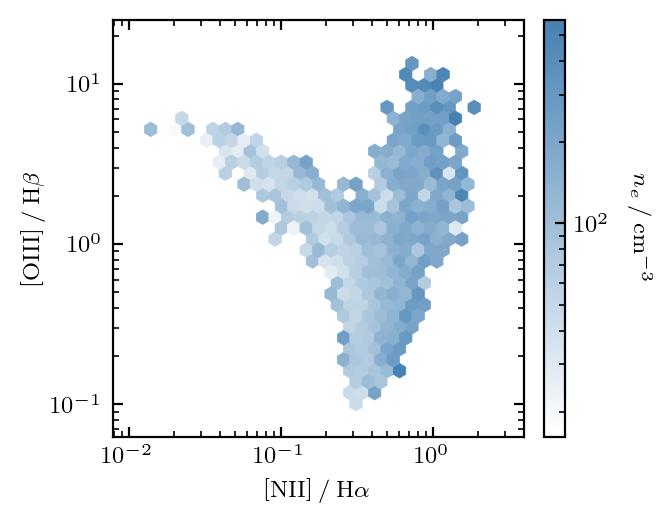

In [15]:
x = df_bpt['nii_h_alpha_ratio']
y = df_bpt['oiii_h_beta_ratio']
z = df_bpt['el_gas_dens']

mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')  

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=SteelBlue_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,                       
    edgecolors='face',
    linewidths=0.25,
    xscale='log',
    yscale='log',
    extent=[xmin_log, xmax_log, ymin_log, ymax_log]
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=2)

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$n_e \mathbin{/} \mathrm{cm}^{-3}$', rotation=270, labelpad=15)

figures['BPT_density'] = fig
plt.close()

figures['BPT_density']

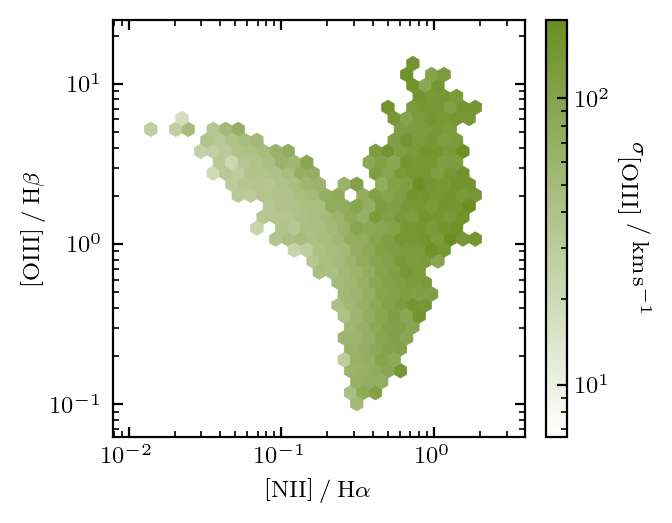

In [16]:
x = df_bpt['nii_h_alpha_ratio']
y = df_bpt['oiii_h_beta_ratio']
z = df_bpt['oiii_sigma']

mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')  

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=OliveDrab_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,                       
    edgecolors='face',
    linewidths=0.25,
    xscale='log',
    yscale='log',
    extent=[xmin_log, xmax_log, ymin_log, ymax_log]
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=2)

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$\sigma_{\mathrm{\raisebox{0.5pt}{[\raisebox{-0.5pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$', rotation=270, labelpad=14.5)

figures['BPT_dispersion'] = fig
plt.close()

figures['BPT_dispersion']

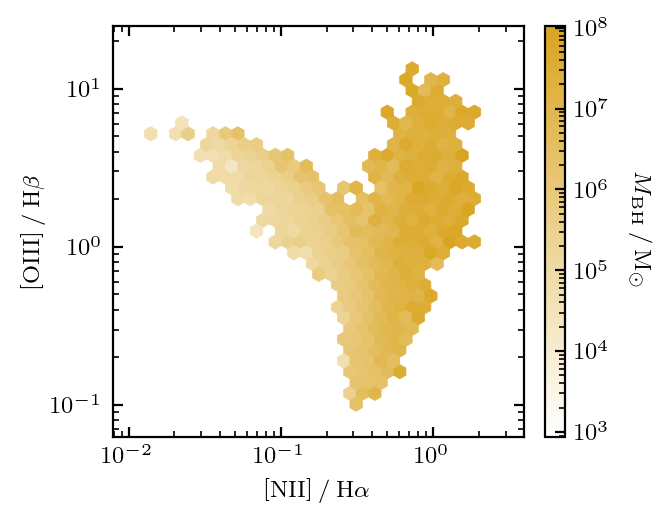

In [17]:
x = df_bpt['nii_h_alpha_ratio']
y = df_bpt['oiii_h_beta_ratio']
z = df_bpt['bh_mass']

mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')  

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=GoldenRod_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,                       
    edgecolors='face',
    linewidths=0.25,
    xscale='log',
    yscale='log',
    extent=[xmin_log, xmax_log, ymin_log, ymax_log]
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=2)

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$M_\mathrm{BH} \mathbin{/} \mathrm{M}_\odot$', rotation=270, labelpad=15)

figures['BPT_mass'] = fig
plt.close()

figures['BPT_mass']

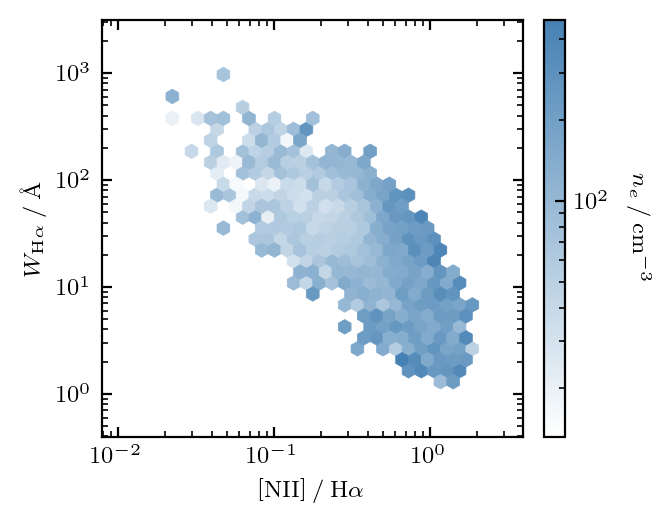

In [18]:
x = df_whan['nii_h_alpha_ratio']
y = -df_whan['h_alpha_eqw']
z = df_whan['el_gas_dens']

mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')  

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -0.4, 3.5

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=SteelBlue_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,                       
    edgecolors='face',
    linewidths=0.25,
    xscale='log',
    yscale='log',
    extent=[xmin_log, xmax_log, ymin_log, ymax_log]
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$W_\mathrm{H\alpha} \mathbin{/} \mathrm{\AA}$')

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$n_e \mathbin{/} \mathrm{cm}^{-3}$', rotation=270, labelpad=15)

figures['WHAN_density'] = fig
plt.close()

figures['WHAN_density']

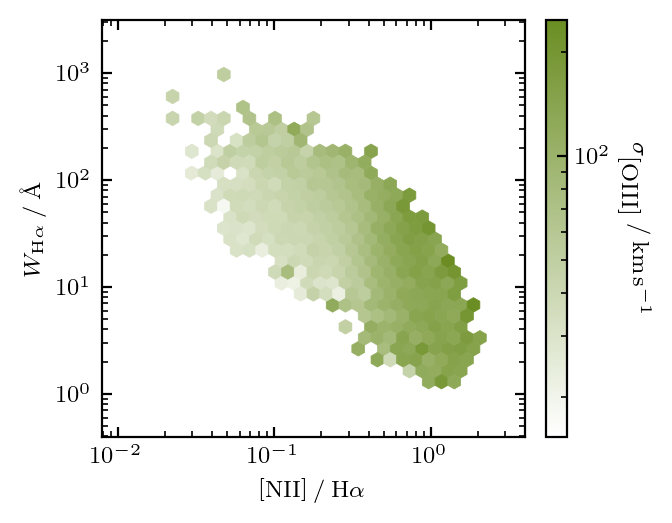

In [19]:
x = df_whan['nii_h_alpha_ratio']
y = -df_whan['h_alpha_eqw']
z = df_whan['oiii_sigma']

mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')  

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -0.4, 3.5

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=OliveDrab_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,                       
    edgecolors='face',
    linewidths=0.25,
    xscale='log',
    yscale='log',
    extent=[xmin_log, xmax_log, ymin_log, ymax_log]
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$W_\mathrm{H\alpha} \mathbin{/} \mathrm{\AA}$')

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$\sigma_{\mathrm{\raisebox{0.5pt}{[\raisebox{-0.5pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$', rotation=270, labelpad=14.5)

figures['WHAN_dispersion'] = fig
plt.close()

figures['WHAN_dispersion']

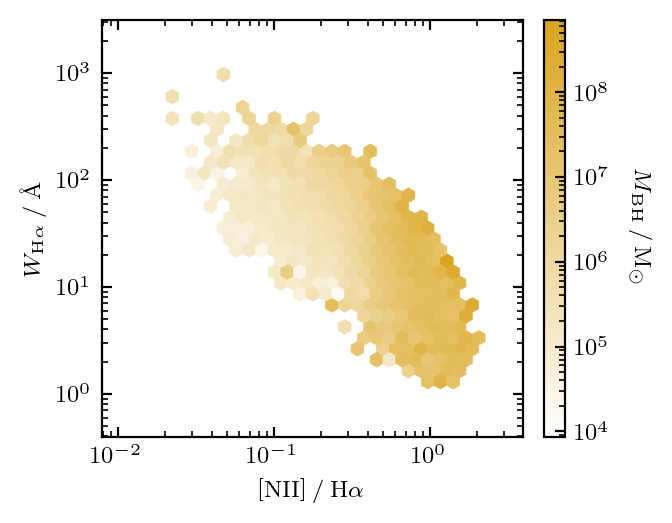

In [20]:
x = df_whan['nii_h_alpha_ratio']
y = -df_whan['h_alpha_eqw']
z = df_whan['bh_mass']

mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')  

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -0.4, 3.5

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=GoldenRod_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,                       
    edgecolors='face',
    linewidths=0.25,
    xscale='log',
    yscale='log',
    extent=[xmin_log, xmax_log, ymin_log, ymax_log]
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**xmin_log, 10**xmax_log)
ax.set_ylim(10**ymin_log, 10**ymax_log)

ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
ax.set_ylabel(r'$W_\mathrm{H\alpha} \mathbin{/} \mathrm{\AA}$')

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$M_\mathrm{BH} \mathbin{/} \mathrm{M}_\odot$', rotation=270, labelpad=15)

figures['WHAN_mass'] = fig
plt.close()

figures['WHAN_mass']

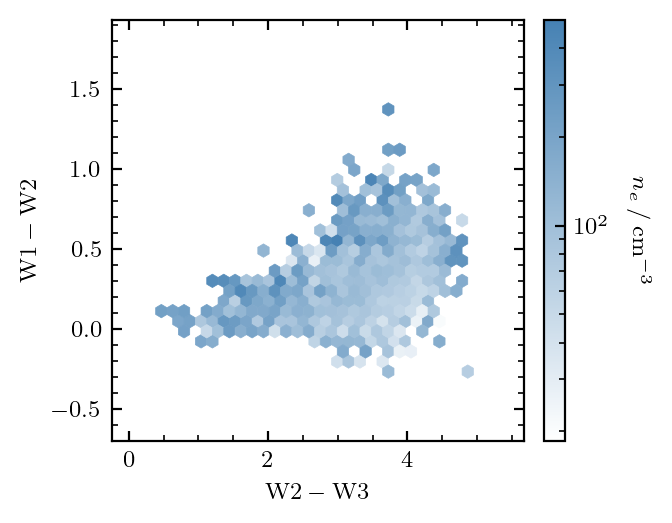

In [21]:
x = df_wise['w2_w3']
y = df_wise['w1_w2']
z = df_wise['el_gas_dens']

mask = (
    np.isfinite(x) & (x > -10) & 
    np.isfinite(y) & (y > -10) & 
    np.isfinite(z) & (z > 0)
)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=SteelBlue_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,            
    edgecolors='face',
    linewidths=0.25
)

ax.set_xlabel(r'$\mathrm{W2 - W3}$')
ax.set_ylabel(r'$\mathrm{W1 - W2}$')

ax.set_xlim(np.array(ax.set_xlim()) - 0.2)

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$n_e \mathbin{/} \mathrm{cm}^{-3}$', rotation=270, labelpad=15)

figures['WISE_density'] = fig
plt.close()

figures['WISE_density']

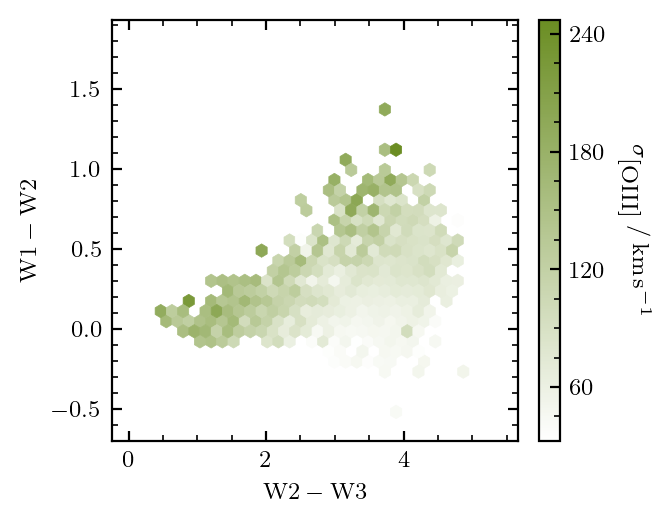

In [22]:
x = df_wise['w2_w3']
y = df_wise['w1_w2']
z = df_wise['oiii_sigma']

mask = (
    np.isfinite(x) & (x > -10) & 
    np.isfinite(y) & (y > -10) & 
    np.isfinite(z) & (z > 0)
)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=OliveDrab_r,
    mincnt=2,                       
    edgecolors='face',
    linewidths=0.25
)

ax.set_xlabel(r'$\mathrm{W2 - W3}$')
ax.set_ylabel(r'$\mathrm{W1 - W2}$')

ax.set_xlim(np.array(ax.set_xlim()) - 0.2)

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1, ticks=[60, 120, 180, 240])
cbar.set_label(r'$\sigma_{\mathrm{\raisebox{0.5pt}{[\raisebox{-0.5pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$', rotation=270, labelpad=16.5)

figures['WISE_dispersion'] = fig
plt.close()

figures['WISE_dispersion']

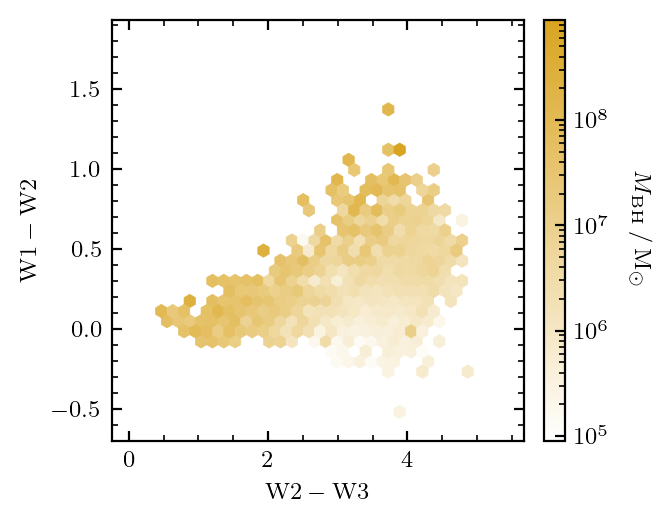

In [23]:
x = df_wise['w2_w3']
y = df_wise['w1_w2']
z = df_wise['bh_mass']

mask = (
    np.isfinite(x) & (x > -10) & 
    np.isfinite(y) & (y > -10) & 
    np.isfinite(z) & (z > 0)
)
x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]

fig, ax = plt.subplots(figsize=[3.25, 2.50])
ax.set_facecolor('white')

hb = ax.hexbin(
    x_clean, y_clean,
    C=z_clean,                       
    reduce_C_function=np.nanmedian, 
    gridsize=33,                    
    cmap=GoldenRod_r,
    norm=mcolors.LogNorm(),          
    mincnt=2,            
    edgecolors='face',
    linewidths=0.25
)

ax.set_xlabel(r'$\mathrm{W2 - W3}$')
ax.set_ylabel(r'$\mathrm{W1 - W2}$')

ax.set_xlim(np.array(ax.set_xlim()) - 0.2)

ax.set_aspect('auto')

cbar = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cbar.set_label(r'$M_\mathrm{BH} \mathbin{/} \mathrm{M}_\odot$', rotation=270, labelpad=15)

figures['WISE_mass'] = fig
plt.close()

figures['WISE_mass']

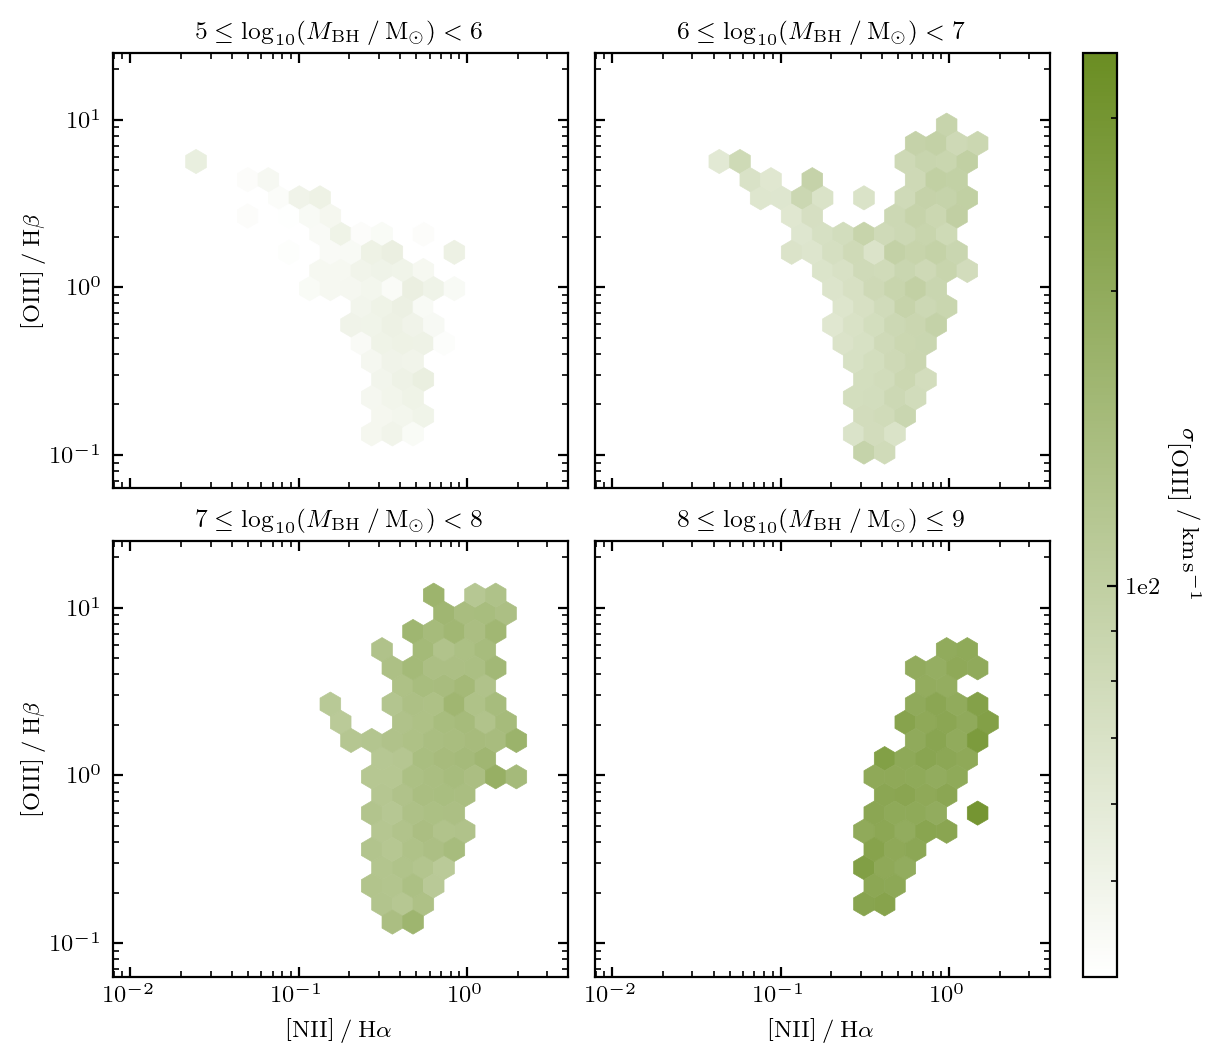

In [24]:
import matplotlib.ticker as mticker

bin_edges = [5.0, 6.0, 7.0, 8.0, 9.0]
titles = [
    r'$5 \le \log_{10}(M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot) < 6$',
    r'$6 \le \log_{10}(M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot) < 7$',
    r'$7 \le \log_{10}(M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot) < 8$',
    r'$8 \le \log_{10}(M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot) \le 9$'
]

global_norm = mcolors.LogNorm(vmin=40, vmax=350)

fig, axes = plt.subplots(2, 2, figsize=[6.69, 6.0], sharex=True, sharey=True, layout='none')
axes_flat = axes.flatten()

xmin_log, xmax_log = -2.1, 0.6
ymin_log, ymax_log = -1.2, 1.4

for i in range(4):
    ax = axes_flat[i]
    ax.set_facecolor('white')
    
    m_lower = 10**bin_edges[i]
    m_upper = 10**bin_edges[i+1]
    mass_mask = (df_bpt['bh_mass'] >= m_lower) & (df_bpt['bh_mass'] < m_upper)
    
    x = df_bpt['nii_h_alpha_ratio'][mass_mask]
    y = df_bpt['oiii_h_beta_ratio'][mass_mask]
    z = df_bpt['oiii_sigma'][mass_mask]
    
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x_clean, y_clean, z_clean = x[mask], y[mask], z[mask]
    
    if len(x_clean) > 0:
        hb = ax.hexbin(
            x_clean, y_clean,
            C=z_clean,                       
            reduce_C_function=np.nanmedian, 
            gridsize=22,                    
            cmap=OliveDrab_r,       
            norm=global_norm,       
            mincnt=2,                       
            edgecolors='face',
            linewidths=0.25,
            xscale='log',
            yscale='log',
            extent=[xmin_log, xmax_log, ymin_log, ymax_log]
        )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(10**xmin_log, 10**xmax_log)
    ax.set_ylim(10**ymin_log, 10**ymax_log)
    ax.set_aspect('auto')
    ax.set_title(titles[i], fontsize=9, pad=5)

for ax in axes[-1, :]:  
    ax.set_xlabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{NII}]}} \mathbin{/} \mathrm{H\alpha}$')
for ax in axes[:, 0]:   
    ax.set_ylabel(r'$\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}} \mathbin{/} \mathrm{H\beta}$', labelpad=2)

fig.subplots_adjust(right=0.825, wspace=0.06, hspace=0.12)  

pos_top = axes[0, 1].get_position()
pos_bottom = axes[1, 1].get_position()
cbar_ax = fig.add_axes([0.85, pos_bottom.y0, 0.025, pos_top.y1 - pos_bottom.y0]) 

cbar = fig.colorbar(hb, cax=cbar_ax)

# Explicitly assign your major tick and format its label
cbar.set_ticks([100])
cbar.ax.set_yticklabels(['1e2'])

# Hide text labels for minor ticks while keeping the tick ticks visible
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())

cbar.set_label(r'$\sigma_{\mathrm{\raisebox{0.5pt}{[\raisebox{-0.5pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$', rotation=270, labelpad=14.5)

figures['BPT_bins'] = fig
plt.close()

figures['BPT_bins']

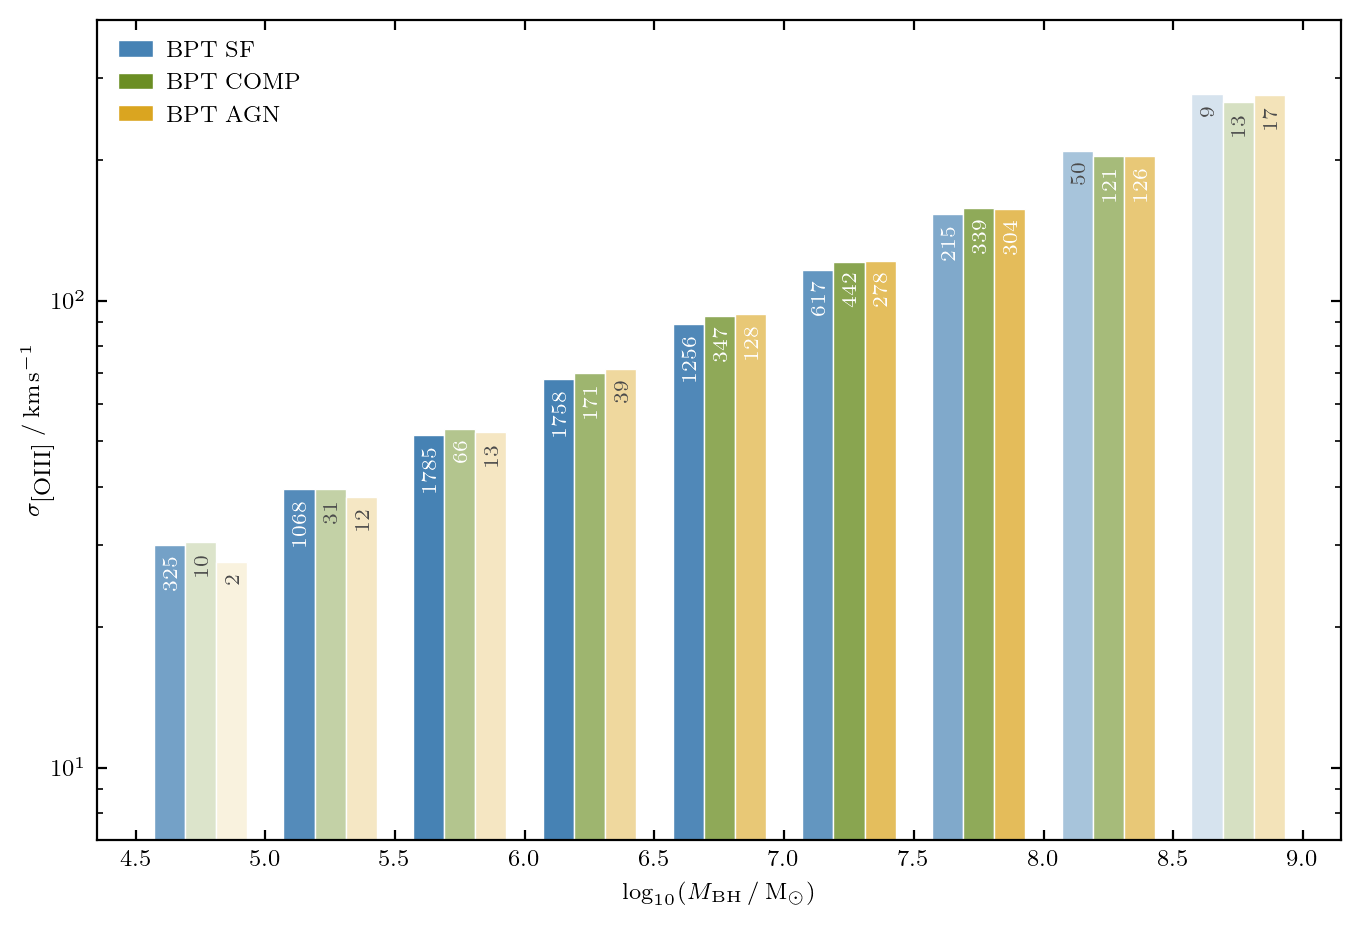

In [25]:
bin_edges = np.arange(4.5, 9.5, 0.5)  
num_bins = len(bin_edges) - 1

bpt_types = ['SF', 'COMP', 'AGN']
type_colors = ['steelblue', 'olivedrab', 'goldenrod']

fig, ax = plt.subplots(figsize=[6.69, 4.51])
ax.set_facecolor('white')

x_indexes = np.arange(num_bins)
bar_width = 0.24

parsed_data = {bpt: [] for bpt in bpt_types}
parsed_counts = {bpt: [] for bpt in bpt_types}
parsed_colors = {bpt: [] for bpt in bpt_types}
parsed_text_colors = {bpt: [] for bpt in bpt_types}

all_counts = []
for i in range(num_bins):
    m_lower = 10**bin_edges[i]
    m_upper = 10**bin_edges[i+1]
    df_bin = df[(df['bh_mass'] >= m_lower) & (df['bh_mass'] < m_upper)]
    
    for bpt_type in bpt_types:
        df_sub = df_bin[df_bin['bpt_class'] == bpt_type]
        
        if not df_sub.empty and 'oiii_sigma' in df_sub.columns:
            clean_mask = np.isfinite(df_sub['oiii_sigma']) & (df_sub['oiii_sigma'] > 0)
            n_samples = np.sum(clean_mask)
            parsed_counts[bpt_type].append(n_samples)
            if n_samples > 0:
                all_counts.append(n_samples)
                parsed_data[bpt_type].append(np.nanmedian(df_sub['oiii_sigma'][clean_mask]))
            else:
                parsed_data[bpt_type].append(0.0)
        else:
            parsed_counts[bpt_type].append(0)
            parsed_data[bpt_type].append(0.0)

log_n_min = np.log10(min(all_counts)) if len(all_counts) > 0 else 0
log_n_max = np.log10(max(all_counts)) if len(all_counts) > 0 else 1
log_n_range = log_n_max - log_n_min if log_n_max != log_n_min else 1

for j, bpt_type in enumerate(bpt_types):
    base_rgb = np.array(mcolors.to_rgb(type_colors[j]))
    white_rgb = np.array([1.0, 1.0, 1.0])
    
    for n_count in parsed_counts[bpt_type]:
        if n_count == 0:
            parsed_colors[bpt_type].append((1.0, 1.0, 1.0))
            parsed_text_colors[bpt_type].append('black')
            continue
            
        log_n = np.log10(n_count)
        fade_weight = np.clip(1.0 - ((log_n - log_n_min) / log_n_range), 0.0, 0.85)
        
        parsed_colors[bpt_type].append((1.0 - fade_weight) * base_rgb + fade_weight * white_rgb)
        parsed_text_colors[bpt_type].append('#4b4b4b' if fade_weight > 0.50 else '#ffffff')

for j, bpt_type in enumerate(bpt_types):
    bar_positions = x_indexes + (j - 1) * bar_width
    
    bars = ax.bar(
        bar_positions, parsed_data[bpt_type],
        width=bar_width,
        label=bpt_type,
        color=parsed_colors[bpt_type],   
        edgecolor='white',             
        linewidth=0.5,
        zorder=-10
    )
    
    for idx, bar in enumerate(bars):
        y_val = bar.get_height()
        n_count = parsed_counts[bpt_type][idx]
        
        if n_count > 0 and y_val > 0:
            ax.text(
                bar.get_x() + bar.get_width()/1.75, 
                y_val * 0.95, 
                f'{n_count}', 
                ha='center', 
                va='top',       
                fontsize=7.5, 
                color=parsed_text_colors[bpt_type][idx],
                weight='medium', 
                rotation=90, 
                zorder=5
            )

ax.set_xticks(np.arange(-0.5, 9, 1))
ax.set_xticklabels(['4.5', '5.0', '5.5', '6.0', '6.5', '7.0', '7.5', '8.0', '8.5', '9.0'])
ax.minorticks_off()

ax.set_xlabel(r'$\log_{10}(M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot)$')
ax.set_ylabel(r'$\sigma_{\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$', labelpad=-0.75)
ax.set_ylim(7e0, 4e2) 

legend_handles = [plt.Rectangle((0,0),1,1, color=c, ec='white', lw=0.5) for c in type_colors]
ax.legend(legend_handles, ['BPT SF', 'BPT COMP', 'BPT AGN'], loc='upper left')
ax.set_yscale('log')

figures['BPT_bar'] = fig
plt.close()

figures['BPT_bar']

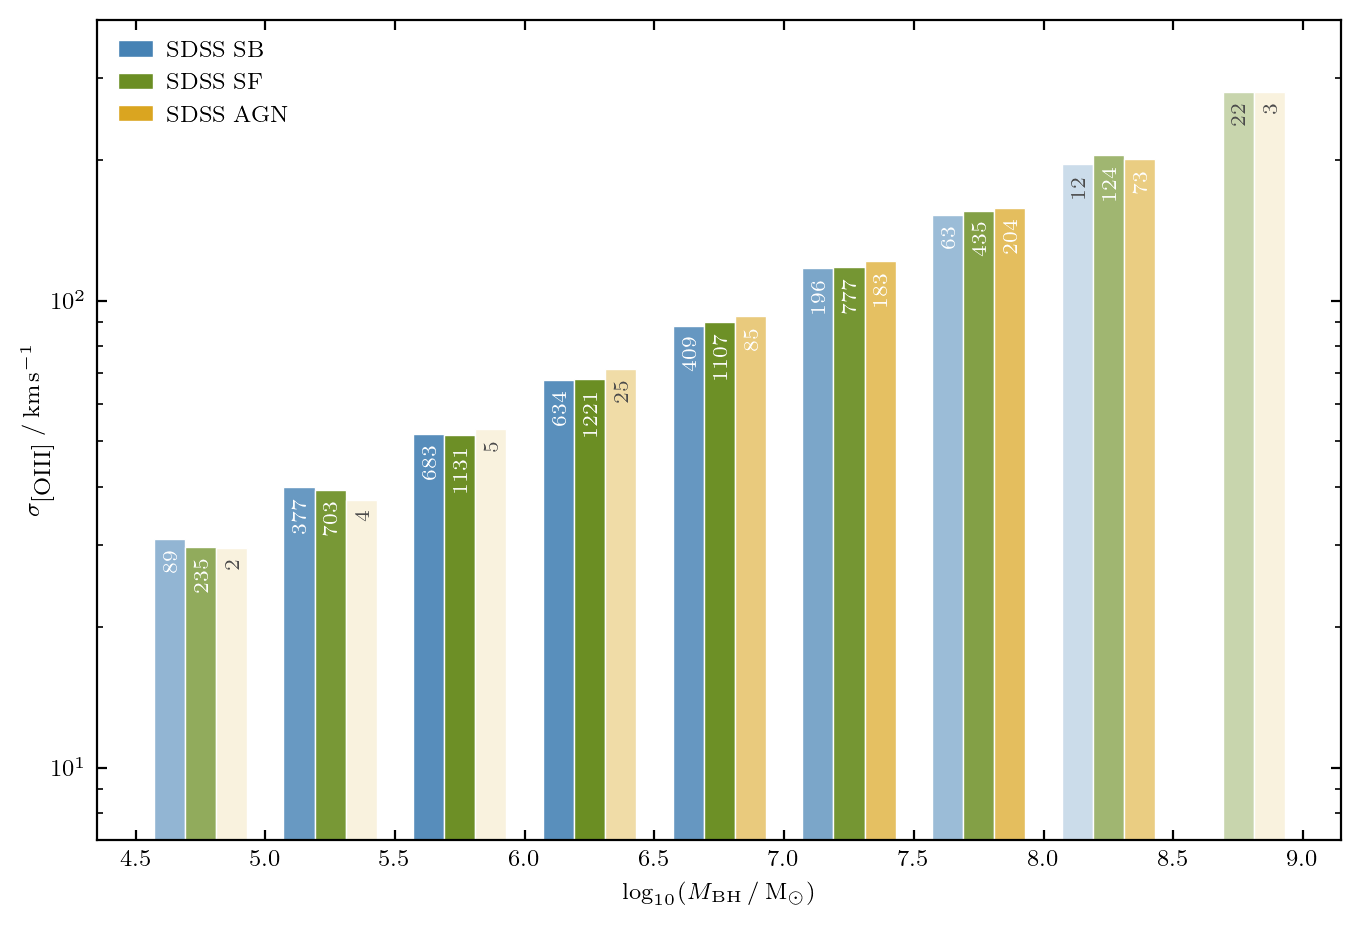

In [26]:
bin_edges = np.arange(4.5, 9.5, 0.5)  
num_bins = len(bin_edges) - 1

sdss_types = ['STARBURST', 'STARFORMING', 'AGN']
type_colors = ['steelblue', 'olivedrab', 'goldenrod']

fig, ax = plt.subplots(figsize=[6.69, 4.51])
ax.set_facecolor('white')

x_indexes = np.arange(num_bins)
bar_width = 0.24

parsed_data = {sdss: [] for sdss in sdss_types}
parsed_counts = {sdss: [] for sdss in sdss_types}
parsed_colors = {sdss: [] for sdss in sdss_types}
parsed_text_colors = {sdss: [] for sdss in sdss_types}

all_counts = []
for i in range(num_bins):
    m_lower = 10**bin_edges[i]
    m_upper = 10**bin_edges[i+1]
    df_bin = df[(df['bh_mass'] >= m_lower) & (df['bh_mass'] < m_upper)]
    
    for sdss_type in sdss_types:
        df_sub = df_bin[df_bin['subclass'] == sdss_type]
        
        if not df_sub.empty and 'oiii_sigma' in df_sub.columns:
            clean_mask = np.isfinite(df_sub['oiii_sigma']) & (df_sub['oiii_sigma'] > 0)
            n_samples = np.sum(clean_mask)
            parsed_counts[sdss_type].append(n_samples)
            if n_samples > 0:
                all_counts.append(n_samples)
                parsed_data[sdss_type].append(np.nanmedian(df_sub['oiii_sigma'][clean_mask]))
            else:
                parsed_data[sdss_type].append(0.0)
        else:
            parsed_counts[sdss_type].append(0)
            parsed_data[sdss_type].append(0.0)

log_n_min = np.log10(min(all_counts)) if len(all_counts) > 0 else 0
log_n_max = np.log10(max(all_counts)) if len(all_counts) > 0 else 1
log_n_range = log_n_max - log_n_min if log_n_max != log_n_min else 1

for j, sdss_type in enumerate(sdss_types):
    base_rgb = np.array(mcolors.to_rgb(type_colors[j]))
    white_rgb = np.array([1.0, 1.0, 1.0])
    
    for n_count in parsed_counts[sdss_type]:
        if n_count == 0:
            parsed_colors[sdss_type].append((1.0, 1.0, 1.0))
            parsed_text_colors[sdss_type].append('black')
            continue
            
        log_n = np.log10(n_count)
        fade_weight = np.clip(1.0 - ((log_n - log_n_min) / log_n_range), 0.0, 0.85)
        
        parsed_colors[sdss_type].append((1.0 - fade_weight) * base_rgb + fade_weight * white_rgb)
        parsed_text_colors[sdss_type].append('#4b4b4b' if fade_weight > 0.50 else '#ffffff')

for j, sdss_type in enumerate(sdss_types):
    bar_positions = x_indexes + (j - 1) * bar_width
    
    bars = ax.bar(
        bar_positions, parsed_data[sdss_type],
        width=bar_width,
        label=sdss_type,
        color=parsed_colors[sdss_type],   
        edgecolor='white',             
        linewidth=0.5,
        zorder=-10
    )
    
    for idx, bar in enumerate(bars):
        y_val = bar.get_height()
        n_count = parsed_counts[sdss_type][idx]
        
        if n_count > 0 and y_val > 0:
            ax.text(
                bar.get_x() + bar.get_width()/1.75, 
                y_val * 0.95, 
                f'{n_count}', 
                ha='center', 
                va='top',       
                fontsize=7.5, 
                color=parsed_text_colors[sdss_type][idx],
                weight='medium', 
                rotation=90, 
                zorder=5
            )

ax.set_xticks(np.arange(-0.5, 9, 1))
ax.set_xticklabels(['4.5', '5.0', '5.5', '6.0', '6.5', '7.0', '7.5', '8.0', '8.5', '9.0'])
ax.minorticks_off()

ax.set_xlabel(r'$\log_{10}(M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot)$')
ax.set_ylabel(r'$\sigma_{\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$', labelpad=-0.75)
ax.set_ylim(7e0, 4e2) 

legend_handles = [plt.Rectangle((0,0),1,1, color=c, ec='white', lw=0.5) for c in type_colors]
ax.legend(legend_handles, ['SDSS SB', 'SDSS SF', 'SDSS AGN'], loc='upper left')
ax.set_yscale('log')

figures['SDSS_bar'] = fig
plt.close()

figures['SDSS_bar']

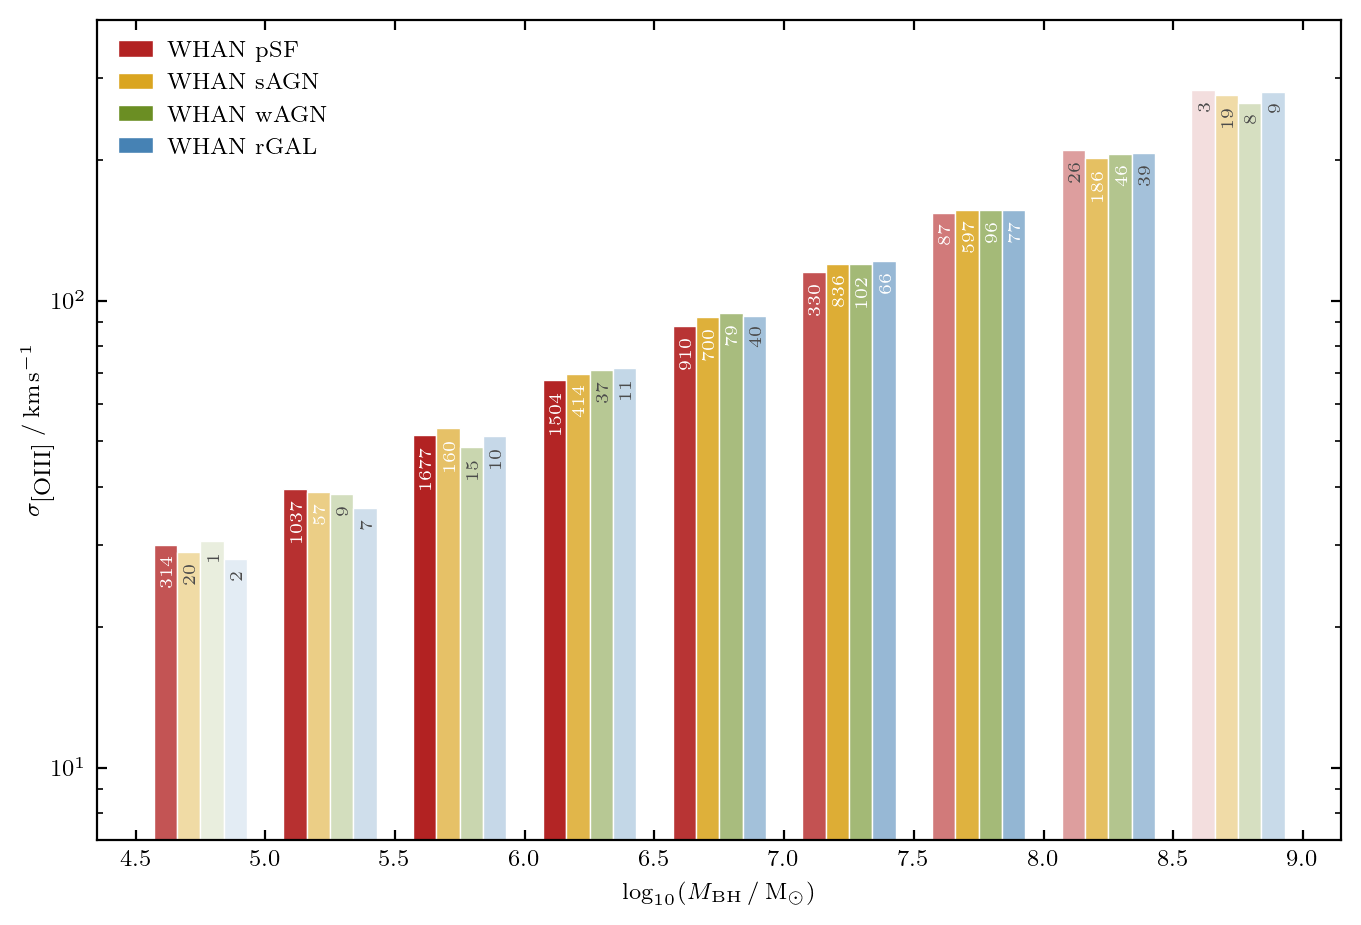

In [27]:
bin_edges = np.arange(4.5, 9.5, 0.5)  
num_bins = len(bin_edges) - 1

whan_types = ['Pure SF', 'Strong AGN', 'Weak AGN', 'Radio G']
type_colors = ['firebrick', 'goldenrod', 'olivedrab', 'steelblue']

fig, ax = plt.subplots(figsize=[6.69, 4.51])
ax.set_facecolor('white')

x_indexes = np.arange(num_bins)
bar_width = 0.18

parsed_data = {whan: [] for whan in whan_types}
parsed_counts = {whan: [] for whan in whan_types}
parsed_colors = {whan: [] for whan in whan_types}
parsed_text_colors = {whan: [] for whan in whan_types}

all_counts = []
for i in range(num_bins):
    m_lower = 10**bin_edges[i]
    m_upper = 10**bin_edges[i+1]
    df_bin = df[(df['bh_mass'] >= m_lower) & (df['bh_mass'] < m_upper)]
    
    for whan_type in whan_types:
        df_sub = df_bin[df_bin['whan_class'] == whan_type]
        
        if not df_sub.empty and 'oiii_sigma' in df_sub.columns:
            clean_mask = np.isfinite(df_sub['oiii_sigma']) & (df_sub['oiii_sigma'] > 0)
            n_samples = np.sum(clean_mask)
            parsed_counts[whan_type].append(n_samples)
            if n_samples > 0:
                all_counts.append(n_samples)
                parsed_data[whan_type].append(np.nanmedian(df_sub['oiii_sigma'][clean_mask]))
            else:
                parsed_data[whan_type].append(0.0)
        else:
            parsed_counts[whan_type].append(0)
            parsed_data[whan_type].append(0.0)

log_n_min = np.log10(min(all_counts)) if len(all_counts) > 0 else 0
log_n_max = np.log10(max(all_counts)) if len(all_counts) > 0 else 1
log_n_range = log_n_max - log_n_min if log_n_max != log_n_min else 1

for j, whan_type in enumerate(whan_types):
    base_rgb = np.array(mcolors.to_rgb(type_colors[j]))
    white_rgb = np.array([1.0, 1.0, 1.0])
    
    for n_count in parsed_counts[whan_type]:
        if n_count == 0:
            parsed_colors[whan_type].append((1.0, 1.0, 1.0))
            parsed_text_colors[whan_type].append('black')
            continue
            
        log_n = np.log10(n_count)
        fade_weight = np.clip(1.0 - ((log_n - log_n_min) / log_n_range), 0.0, 0.85)
        
        parsed_colors[whan_type].append((1.0 - fade_weight) * base_rgb + fade_weight * white_rgb)
        parsed_text_colors[whan_type].append('#4b4b4b' if fade_weight > 0.50 else '#ffffff')

for j, whan_type in enumerate(whan_types):
    bar_positions = x_indexes + (j - 1.5) * bar_width
    
    bars = ax.bar(
        bar_positions, parsed_data[whan_type],
        width=bar_width,
        label=whan_type,
        color=parsed_colors[whan_type],   
        edgecolor='white',             
        linewidth=0.5,
        zorder=-10
    )
    
    for idx, bar in enumerate(bars):
        y_val = bar.get_height()
        n_count = parsed_counts[whan_type][idx]
        
        if n_count > 0 and y_val > 0:
            ax.text(
                bar.get_x() + bar.get_width()/1.7, 
                y_val * 0.95, 
                f'{n_count}', 
                ha='center', 
                va='top',       
                fontsize=6.5, 
                color=parsed_text_colors[whan_type][idx],
                weight='medium', 
                rotation=90, 
                zorder=5
            )

ax.set_xticks(np.arange(-0.5, 9, 1))
ax.set_xticklabels(['4.5', '5.0', '5.5', '6.0', '6.5', '7.0', '7.5', '8.0', '8.5', '9.0'])
ax.minorticks_off()

ax.set_xlabel(r'$\log_{10}(M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot)$')
ax.set_ylabel(r'$\sigma_{\mathrm{\raisebox{0.75pt}{[\raisebox{-0.75pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$', labelpad=-0.75)
ax.set_ylim(7e0, 4e2) 

legend_handles = [plt.Rectangle((0,0),1,1, color=c, ec='white', lw=0.5) for c in type_colors]
ax.legend(legend_handles, ['WHAN pSF', 'WHAN sAGN', 'WHAN wAGN', 'WHAN rGAL'], loc='upper left')
ax.set_yscale('log')

figures['WHAN_bar'] = fig
plt.close()

figures['WHAN_bar']

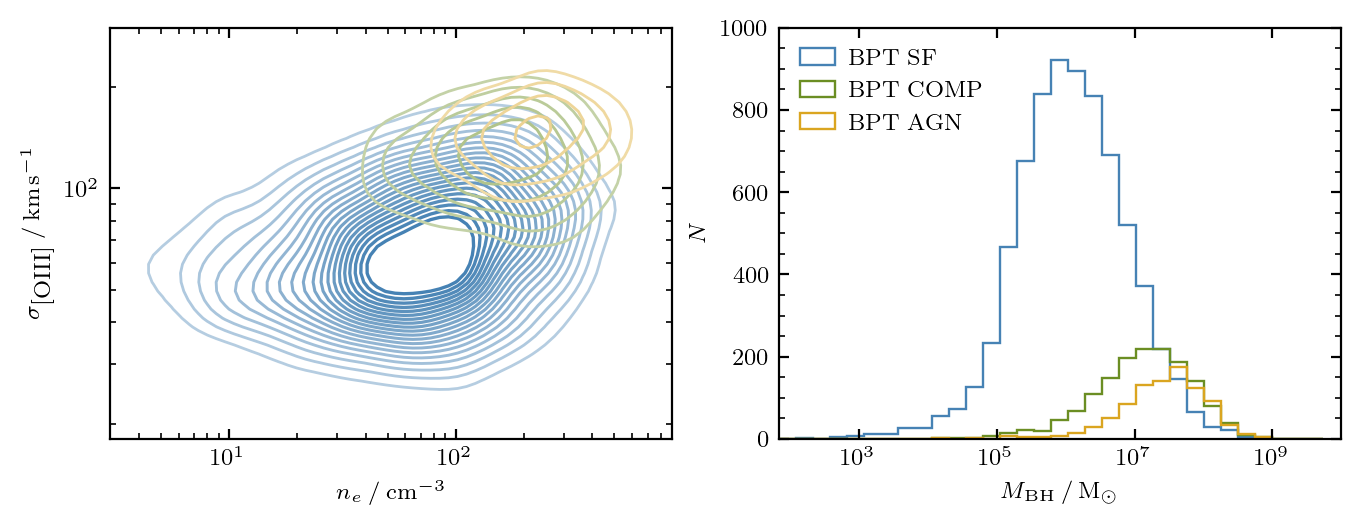

In [28]:
bpt_classes = ['SF', 'COMP', 'AGN']
legend_labels = ['BPT SF', 'BPT COMP', 'BPT AGN']
type_colors = ['steelblue', 'olivedrab', 'goldenrod']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6.69, 2.51])
ax1.set_facecolor('white')
ax2.set_facecolor('white')

class_data_2d = {}
class_data_1d = {}
all_x_logs = []
all_y_logs = []
all_m_raw = []

for cls in bpt_classes:
    df_sub = df[df['bpt_class'] == cls]
    if not df_sub.empty:
        if 'el_gas_dens' in df_sub.columns and 'oiii_sigma' in df_sub.columns:
            x_raw = df_sub['el_gas_dens'].to_numpy()
            y_raw = df_sub['oiii_sigma'].to_numpy()
            mask_2d = (x_raw > 0) & (y_raw > 0) & np.isfinite(x_raw) & np.isfinite(y_raw)
            if np.sum(mask_2d) > 10:
                x_log = np.log10(x_raw[mask_2d])
                y_log = np.log10(y_raw[mask_2d])
                class_data_2d[cls] = (x_log, y_log)
                all_x_logs.extend(x_log)
                all_y_logs.extend(y_log)
                
        if 'bh_mass' in df_sub.columns:
            m_raw = df_sub['bh_mass'].to_numpy()
            mask_1d = (m_raw > 0) & np.isfinite(m_raw)
            if np.sum(mask_1d) > 0:
                class_data_1d[cls] = m_raw[mask_1d]
                all_m_raw.extend(m_raw[mask_1d])

if all_x_logs and all_y_logs:
    x_bins = np.linspace(min(all_x_logs), max(all_x_logs), 100)
    y_bins = np.linspace(min(all_y_logs), max(all_y_logs), 100)
    
    x_cen = 10**(0.5 * (x_bins[:-1] + x_bins[1:]))
    y_cen = 10**(0.5 * (y_bins[:-1] + y_bins[1:]))
    
    smoothed_grids = {}
    global_max_density = 0.0
    
    for cls, (x_log, y_log) in class_data_2d.items():
        counts, _, _ = np.histogram2d(x_log, y_log, bins=[x_bins, y_bins])
        smoothed_counts = gaussian_filter(counts, sigma=2.5)
        smoothed_grids[cls] = smoothed_counts
        if smoothed_counts.max() > global_max_density:
            global_max_density = smoothed_counts.max()
            
    n_levels = 20
    contour_levels = np.linspace(0.10 * global_max_density, 0.85 * global_max_density, n_levels)

    for j, cls in enumerate(bpt_classes):
        if cls in smoothed_grids:
            base_rgb = mcolors.to_rgb(type_colors[j])
            
            level_colors = []
            for i in range(n_levels):
                w = 0.4 + 0.6 * (i / (n_levels - 1))
                mixed_rgb = tuple(w * c + (1.0 - w) * 1.0 for c in base_rgb)
                level_colors.append(mixed_rgb)

            level_lws = [
                1.0 + 0.2 * (i / (n_levels - 1))
                for i in range(n_levels)
            ]
            
            ax1.contour(
                x_cen, y_cen, smoothed_grids[cls].T, 
                levels=contour_levels, 
                colors=level_colors, 
                linewidths=level_lws
            )

if all_m_raw:
    bh_bins = np.logspace(np.log10(min(all_m_raw)), np.log10(max(all_m_raw)), 45)
    
    for j, cls in enumerate(bpt_classes):
        if cls in class_data_1d:
            ax2.hist(
                class_data_1d[cls], 
                bins=bh_bins, 
                histtype='step', 
                color=type_colors[j], 
                label=legend_labels[j], 
                linewidth=0.85,
                zorder=-3
            )

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$n_e \mathbin{/} \mathrm{cm}^{-3}$')
ax1.set_ylabel(r'$\sigma_{\mathrm{\raisebox{0.5pt}{[\raisebox{-0.5pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$')
ax1.set_xlim(3e0, 9e2)
ax1.set_ylim(1.8e1, 3e2)

ax2.set_xscale('log')
ax2.set_xlabel(r'$M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot$')
ax2.set_ylabel(r'$N$')
ax2.set_xlim(7e1, 1e10)
ax2.set_ylim(0, 1e3)
ax2.legend(loc='upper left')

figures['BPT_multipanel'] = fig
plt.close()

figures['BPT_multipanel']

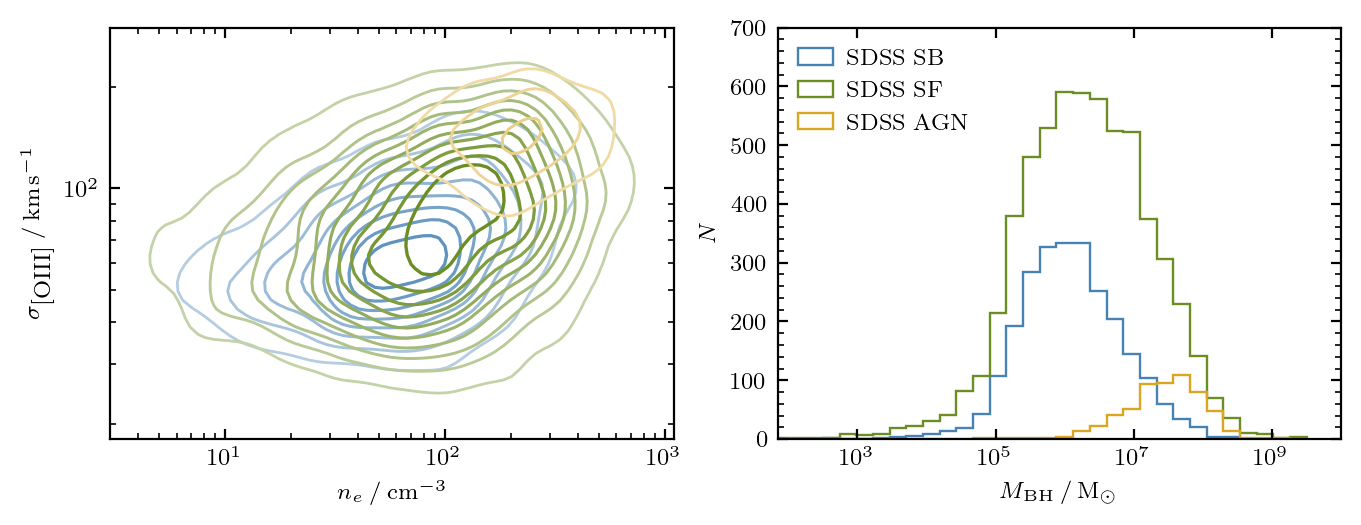

In [29]:
sdss_classes = ['STARBURST', 'STARFORMING', 'AGN']
legend_labels = ['SDSS SB', 'SDSS SF', 'SDSS AGN']
type_colors = ['steelblue', 'olivedrab', 'goldenrod']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6.69, 2.51])
ax1.set_facecolor('white')
ax2.set_facecolor('white')

class_data_2d = {}
class_data_1d = {}
all_x_logs = []
all_y_logs = []
all_m_raw = []

for cls in sdss_classes:
    df_sub = df[df['subclass'] == cls]
    if not df_sub.empty:
        if 'el_gas_dens' in df_sub.columns and 'oiii_sigma' in df_sub.columns:
            x_raw = df_sub['el_gas_dens'].to_numpy()
            y_raw = df_sub['oiii_sigma'].to_numpy()
            mask_2d = (x_raw > 0) & (y_raw > 0) & np.isfinite(x_raw) & np.isfinite(y_raw)
            if np.sum(mask_2d) > 10:
                x_log = np.log10(x_raw[mask_2d])
                y_log = np.log10(y_raw[mask_2d])
                class_data_2d[cls] = (x_log, y_log)
                all_x_logs.extend(x_log)
                all_y_logs.extend(y_log)
                
        if 'bh_mass' in df_sub.columns:
            m_raw = df_sub['bh_mass'].to_numpy()
            mask_1d = (m_raw > 0) & np.isfinite(m_raw)
            if np.sum(mask_1d) > 0:
                class_data_1d[cls] = m_raw[mask_1d]
                all_m_raw.extend(m_raw[mask_1d])

if all_x_logs and all_y_logs:
    x_bins = np.linspace(min(all_x_logs), max(all_x_logs), 100)
    y_bins = np.linspace(min(all_y_logs), max(all_y_logs), 100)
    
    x_cen = 10**(0.5 * (x_bins[:-1] + x_bins[1:]))
    y_cen = 10**(0.5 * (y_bins[:-1] + y_bins[1:]))
    
    smoothed_grids = {}
    global_max_density = 0.0
    
    for cls, (x_log, y_log) in class_data_2d.items():
        counts, _, _ = np.histogram2d(x_log, y_log, bins=[x_bins, y_bins])
        smoothed_counts = gaussian_filter(counts, sigma=2.5)
        smoothed_grids[cls] = smoothed_counts
        if smoothed_counts.max() > global_max_density:
            global_max_density = smoothed_counts.max()
            
    n_levels = 10
    contour_levels = np.linspace(0.10 * global_max_density, 0.85 * global_max_density, n_levels)

    for j, cls in enumerate(sdss_classes):
        if cls in smoothed_grids:
            base_rgb = mcolors.to_rgb(type_colors[j])
            
            level_colors = []
            for i in range(n_levels):
                w = 0.4 + 0.6 * (i / (n_levels - 1))
                mixed_rgb = tuple(w * c + (1.0 - w) * 1.0 for c in base_rgb)
                level_colors.append(mixed_rgb)

            level_lws = [
                1.0 + 0.2 * (i / (n_levels - 1))
                for i in range(n_levels)
            ]
            
            ax1.contour(
                x_cen, y_cen, smoothed_grids[cls].T, 
                levels=contour_levels, 
                colors=level_colors, 
                linewidths=level_lws
            )

if all_m_raw:
    bh_bins = np.logspace(np.log10(min(all_m_raw)), np.log10(max(all_m_raw)), 45)
    
    for j, cls in enumerate(sdss_classes):
        if cls in class_data_1d:
            ax2.hist(
                class_data_1d[cls], 
                bins=bh_bins, 
                histtype='step', 
                color=type_colors[j], 
                label=legend_labels[j], 
                linewidth=0.85,
                zorder=-3
            )

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$n_e \mathbin{/} \mathrm{cm}^{-3}$')
ax1.set_ylabel(r'$\sigma_{\mathrm{\raisebox{0.5pt}{[\raisebox{-0.5pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$')
ax1.set_xlim(3e0, 1.1e3)
ax1.set_ylim(1.8e1, 3e2)

ax2.set_xscale('log')
ax2.set_xlabel(r'$M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot$')
ax2.set_ylabel(r'$N$')
ax2.set_xlim(7e1, 1e10)
ax2.set_ylim(0, 7e2)
ax2.legend(loc='upper left')

figures['SDSS_multipanel'] = fig
plt.close()

figures['SDSS_multipanel']

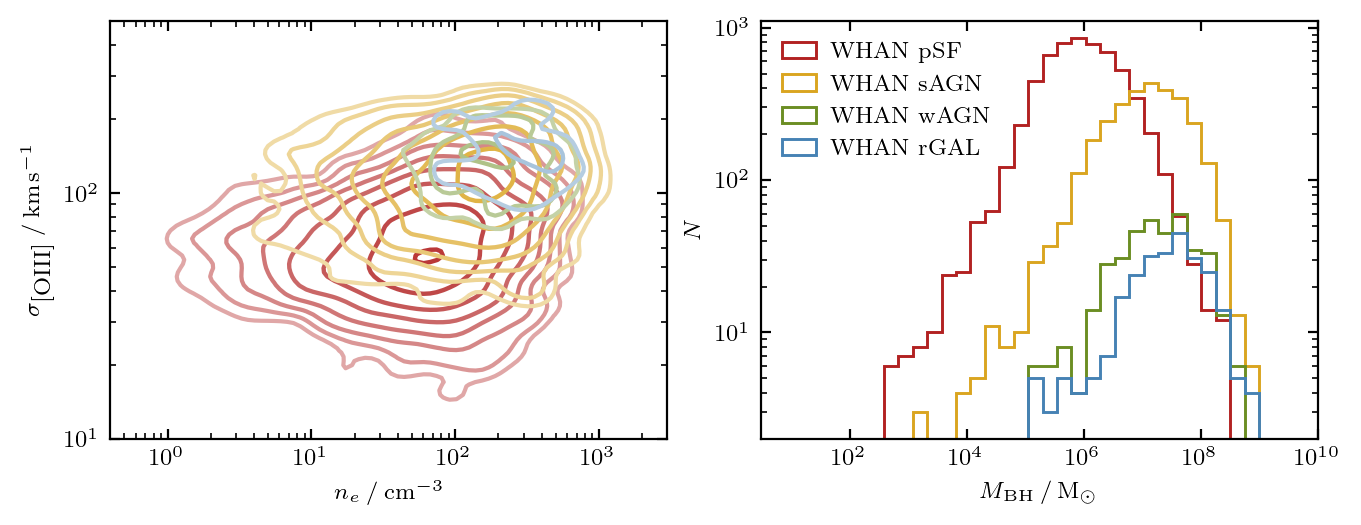

In [30]:
whan_classes = ['Pure SF', 'Strong AGN', 'Weak AGN', 'Radio G']
legend_labels = ['WHAN pSF', 'WHAN sAGN', 'WHAN wAGN', 'WHAN rGAL']
type_colors = ['firebrick', 'goldenrod', 'olivedrab', 'steelblue']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6.69, 2.51])
ax1.set_facecolor('white')
ax2.set_facecolor('white')

class_data_2d = {}
class_data_1d = {}
all_x_logs = []
all_y_logs = []
all_m_raw = []

for cls in whan_classes:
    df_sub = df[df['whan_class'] == cls]
    if not df_sub.empty:
        if 'el_gas_dens' in df_sub.columns and 'oiii_sigma' in df_sub.columns:
            x_raw = df_sub['el_gas_dens'].to_numpy()
            y_raw = df_sub['oiii_sigma'].to_numpy()
            mask_2d = (x_raw > 0) & (y_raw > 0) & np.isfinite(x_raw) & np.isfinite(y_raw)
            if np.sum(mask_2d) > 10:
                x_log = np.log10(x_raw[mask_2d])
                y_log = np.log10(y_raw[mask_2d])
                class_data_2d[cls] = (x_log, y_log)
                all_x_logs.extend(x_log)
                all_y_logs.extend(y_log)
                
        if 'bh_mass' in df_sub.columns:
            m_raw = df_sub['bh_mass'].to_numpy()
            mask_1d = (m_raw > 0) & np.isfinite(m_raw)
            if np.sum(mask_1d) > 0:
                class_data_1d[cls] = m_raw[mask_1d]
                all_m_raw.extend(m_raw[mask_1d])

if all_x_logs and all_y_logs:
    x_bins = np.linspace(np.log10(1e-1), np.log10(3e3), 100)
    y_bins = np.linspace(np.log10(1e1), np.log10(5e2), 100)
    
    x_cen = 10**(0.5 * (x_bins[:-1] + x_bins[1:]))
    y_cen = 10**(0.5 * (y_bins[:-1] + y_bins[1:]))
    
    smoothed_grids = {}
    global_max_density = 0.0
    
    for cls, (x_log, y_log) in class_data_2d.items():
        counts, _, _ = np.histogram2d(x_log, y_log, bins=[x_bins, y_bins])
        smoothed_counts = gaussian_filter(counts, sigma=2.5)
        smoothed_grids[cls] = smoothed_counts
        if smoothed_counts.max() > global_max_density:
            global_max_density = smoothed_counts.max()
            
    n_levels = 8
    contour_levels = np.logspace(np.log10(0.02 * global_max_density), np.log10(0.98 * global_max_density), n_levels)

    for j, cls in enumerate(whan_classes):
        if cls in smoothed_grids:
            base_rgb = mcolors.to_rgb(type_colors[j])
            
            level_colors = []
            for i in range(n_levels):
                w = 0.4 + 0.5 * (i / (n_levels - 1))
                mixed_rgb = tuple(w * c + (1.0 - w) * 1.0 for c in base_rgb)
                level_colors.append(mixed_rgb)

            level_lws = [
                1.5 + 0.1 * (i / (n_levels - 1))
                for i in range(n_levels)
            ]
            
            ax1.contour(
                x_cen, y_cen, smoothed_grids[cls].T, 
                levels=contour_levels, 
                colors=level_colors, 
                linewidths=level_lws
            )

if all_m_raw:
    bh_bins = np.logspace(np.log10(min(all_m_raw)), np.log10(max(all_m_raw)), 45)
    
    for j, cls in enumerate(whan_classes):
        if cls in class_data_1d:
            ax2.hist(
                class_data_1d[cls], 
                bins=bh_bins, 
                histtype='step', 
                color=type_colors[j], 
                label=legend_labels[j], 
                linewidth=1.05,
                zorder=-3
            )

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$n_e \mathbin{/} \mathrm{cm}^{-3}$')
ax1.set_ylabel(r'$\sigma_{\mathrm{\raisebox{0.5pt}{[\raisebox{-0.5pt}{OIII}]}}} \mathbin{/} \mathrm{km}\kern+1pt\mathrm{s}^{-1}$')
ax1.set_xlim(4e-1, 3e3)
ax1.set_ylim(1e1, 5e2)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$M_{\mathrm{BH}} \mathbin{/} \mathrm{M}_\odot$')
ax2.set_ylabel(r'$N$')
ax2.set_xlim(3e0, 1e10)
ax2.set_ylim(2e0, 1.1e3)
ax2.legend(loc='upper left')

figures['WHAN_multipanel'] = fig
plt.close()

figures['WHAN_multipanel']

In [31]:
i = 0
for key, value in figures.items():
    i += 1
    print(f"{i:2.0f} | Key: {key:<15} | Value: {value}")

 1 | Key: BPT_scatter     | Value: Figure(325x244)
 2 | Key: BPT_class       | Value: Figure(325x244)
 3 | Key: BPT_WHAN_class  | Value: Figure(325x244)
 4 | Key: BPT_SDSS_class  | Value: Figure(325x244)
 5 | Key: WHAN_scatter    | Value: Figure(325x244)
 6 | Key: WHAN_class      | Value: Figure(325x244)
 7 | Key: WHAN_BPT_class  | Value: Figure(325x244)
 8 | Key: WHAN_SDSS_class | Value: Figure(325x244)
 9 | Key: WISE_overlay    | Value: Figure(669x451)
10 | Key: MCC_strict      | Value: Figure(325x325)
11 | Key: MCC_relaxed     | Value: Figure(325x325)
12 | Key: BPT_density     | Value: Figure(325x250)
13 | Key: BPT_dispersion  | Value: Figure(325x250)
14 | Key: BPT_mass        | Value: Figure(325x250)
15 | Key: WHAN_density    | Value: Figure(325x250)
16 | Key: WHAN_dispersion | Value: Figure(325x250)
17 | Key: WHAN_mass       | Value: Figure(325x250)
18 | Key: WISE_density    | Value: Figure(325x250)
19 | Key: WISE_dispersion | Value: Figure(325x250)
20 | Key: WISE_mass       | Val